# WYZ Prime Commerce — Análise Exploratória de Dados
**WYZ Prime Commerce — Case Técnico de Análise de Dados**

---

## Sumário do Notebook

1. Importações e Configurações
2. Carregamento dos Dados
3. Tratamento e Limpeza
4. Análise Exploratória Geral
5. Q1–3: Satisfação do Cliente por Categoria
6. Q4–5: Sazonalidade e Público — Home and Lifestyle
7. Q6: Foco de Marketing (Margem × Ticket × Volume)
8. Q7–8: Reativação de Clientes Inativos
9. Q9–10: Insights Adicionais e Estratégias
10. Benchmarking com Dados Públicos Externos
11. Exportação das Bases para PBI

---
## 1. Importações e Configurações

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# configuração de estilo para gráficos
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

# definição da paleta de cores pela marca
COLORS = {
    'blue':   '#0033CC',
    'green':  '#4CAF50',
    'yellow': '#FFC107',
    'red':    '#E53935',
    'gray':   '#757575',
    'light':  '#E3F2FD',
    'dark':   '#1A237E' 
}
PALETTE = ['#0033CC','#4CAF50','#FFC107','#E53935','#9C27B0','#FF5722', '#1A237E']

FILE_PATH = r'C:\Users\LENOVO\Documents\case_agibank\WYZ Prime Commerce.xlsx'

---
## 2. Carregamento dos Dados

In [90]:
# carregando os dados em dataframes
df_sales_raw   = pd.read_excel(FILE_PATH, sheet_name='sales_customer_invoices')
df_products    = pd.read_excel(FILE_PATH, sheet_name='product_catalog')
df_customers   = pd.read_excel(FILE_PATH, sheet_name='customer_base')
df_dict        = pd.read_excel(FILE_PATH, sheet_name='data_dictionary')

print(f'sales_customer_invoices : {df_sales_raw.shape[0]:,} linhas × {df_sales_raw.shape[1]} colunas')
print(f'product_catalog         : {df_products.shape[0]} linhas × {df_products.shape[1]} colunas')
print(f'customer_base           : {df_customers.shape[0]:,} linhas × {df_customers.shape[1]} colunas')

sales_customer_invoices : 2,587 linhas × 18 colunas
product_catalog         : 6 linhas × 3 colunas
customer_base           : 9,167 linhas × 5 colunas


In [91]:
# observando as tabelas
print('--- VENDAS ---')
display(df_sales_raw.head(3))
print('--- PRODUTOS ---')
display(df_products.head(3))
print('--- CLIENTES ---')
display(df_customers.head(3))

--- VENDAS ---


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Customer ID
0,943-89-2619,B,Yangon,Member,Female,Fashion accessories,120,6,0.05,756.0,2021-01-01,11:46:00,Ewallet,720,18.089,36.0,5.8,CUST-0815
1,133-68-8242,B,Naypyitaw,Member,Female,Home and lifestyle,200,5,0.05,1050.0,2021-01-02,13:30:00,Cash,1000,6.014,50.0,7.9,CUST-0155
2,114-51-5340,B,Naypyitaw,Member,Male,Sports and travel,180,8,0.05,1512.0,2021-01-03,15:50:00,Credit card,1440,15.045,72.0,5.2,CUST-0399


--- PRODUTOS ---


,Product line,gross margin percentage,Unit price
0,Electronic accessories,12.423,30
1,Fashion accessories,18.089,120
2,Food and beverages,2.064,15


--- CLIENTES ---


,Customer ID,Age,Gender,Annual Income (USD),Social Class
0,CUST-0000,22,Male,97582,Middle
1,CUST-0001,39,Male,57387,Middle
2,CUST-0002,37,Female,54400,Middle


---
## 3. Tratamento e Limpeza dos Dados

### 3.1 Verificação dos tipos e quantidade de nulos

In [92]:
# df_sales_raw
print('TIPOS DE DADOS — VENDAS')
print(df_sales_raw.dtypes)
print()
print('VALORES NULOS — VENDAS')
print(df_sales_raw.isnull().sum())

TIPOS DE DADOS — VENDAS
Invoice ID                            str
Branch                                str
City                                  str
Customer type                         str
Gender                                str
Product line                          str
Unit price                          int64
Quantity                            int64
Tax                               float64
Total                             float64
Date                       datetime64[us]
Time                               object
Payment                               str
cogs                                int64
gross margin percentage           float64
gross income                      float64
Rating                            float64
Customer ID                           str
dtype: object

VALORES NULOS — VENDAS
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit pri

### 3.2 Conversão dos tipos em um novo dataframe

In [93]:
# criando uma cópia para manipulação
df_sales = df_sales_raw.copy()

# Date → datetime
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# granularidade temporal
df_sales['Year']    = df_sales['Date'].dt.year
df_sales['Month']   = df_sales['Date'].dt.month
df_sales['Month_Name'] = df_sales['Date'].dt.strftime('%b')
df_sales['Quarter'] = df_sales['Date'].dt.quarter
df_sales['Weekday'] = df_sales['Date'].dt.day_name()

# padronizando nomes de colunas em snake_case
df_sales.rename(columns={
    'Invoice ID': 'invoice_id',
    'Branch': 'branch',
    'City': 'city',
    'Customer type': 'customer_type',
    'Gender': 'gender',
    'Product line': 'product_line',
    'Unit price': 'unit_price',
    'Quantity': 'quantity',
    'Tax': 'tax',
    'Total': 'total',
    'Date': 'date',
    'Time': 'time',
    'Payment': 'payment',
    'cogs': 'cogs',
    'gross margin percentage': 'gross_margin_pct',
    'gross income': 'gross_income',
    'Rating': 'rating',
    'Customer ID': 'customer_id',
}, inplace=True)

df_customers.columns = ['customer_id','age','gender','annual_income','social_class'] + \
                       list(df_customers.columns[5:])
df_customers = df_customers[['customer_id','age','gender','annual_income','social_class']].dropna(subset=['customer_id'])

df_products.columns = ['product_line','gross_margin_pct','unit_price']

print('Tipos após conversão:')
print(df_sales[['date','Year','Month','total','quantity','rating']].dtypes)

Tipos após conversão:
date        datetime64[us]
Year                 int32
Month                int32
total              float64
quantity             int64
rating             float64
dtype: object


### 3.3 Detecção e Remoção de Outliers

Abordagem em 3 etapas progressivas:
1. **Inspeção visual** — boxplot e histograma
2. **Métodos estatísticos** — IQR e Z-score
3. **Decisão contextualizada** — validação pelo domínio do negócio

Estatísticas descritivas — quantity:
count      2587.00
mean         44.15
std        1965.98
min           1.00
25%           3.00
50%           5.00
75%           8.00
max      100000.00
Name: quantity, dtype: float64

Estatísticas descritivas — total ($):
count        2587.00
mean         8738.62
std        412865.52
min            15.52
25%           155.25
50%           472.50
75%           945.00
max      21000000.00
Name: total, dtype: float64


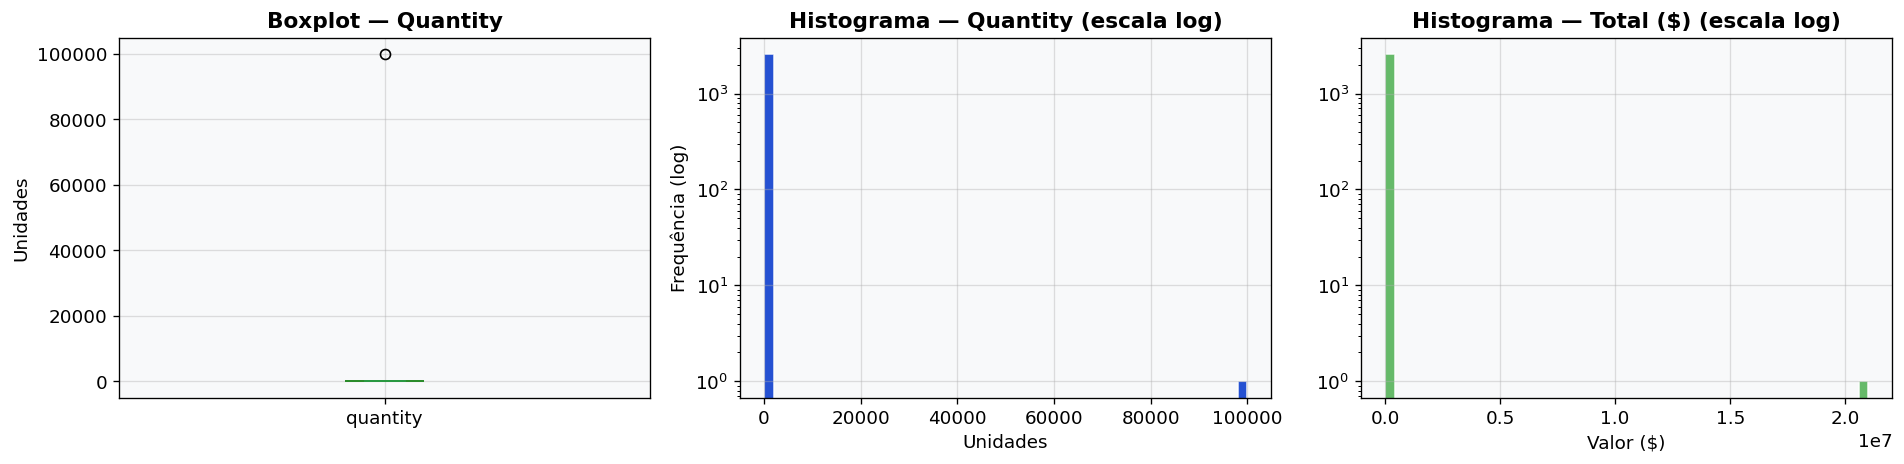

In [94]:
# inspeção visual
print('Estatísticas descritivas — quantity:')
print(df_sales['quantity'].describe().round(2))
print()
print('Estatísticas descritivas — total ($):')
print(df_sales['total'].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# boxplot das quantidades
df_sales['quantity'].plot.box(ax=axes[0], vert=True, patch_artist=True,
                               boxprops=dict(facecolor=COLORS['light']))
axes[0].set_title('Boxplot — Quantity')
axes[0].set_ylabel('Unidades')

# histograma das quantidades em escala log (evidenciando o outlier)
axes[1].hist(df_sales['quantity'], bins=50, color=COLORS['blue'], edgecolor='white', alpha=0.85)
axes[1].set_title('Histograma — Quantity (escala log)')
axes[1].set_xlabel('Unidades')
axes[1].set_yscale('log')
axes[1].set_ylabel('Frequência (log)')

# histograma total
axes[2].hist(df_sales['total'], bins=50, color=COLORS['green'], edgecolor='white', alpha=0.85)
axes[2].set_title('Histograma — Total ($) (escala log)')
axes[2].set_xlabel('Valor ($)')
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('fig_outlier_01_visual.png', bbox_inches='tight')
plt.show()

In [95]:
# métodos estatísticos — IQR e Z-score
from scipy import stats

# IQR (distancia interquartil): outlier = fora de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
Q1 = df_sales['quantity'].quantile(0.25)
Q3 = df_sales['quantity'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
mask_iqr = (df_sales['quantity'] < lower_iqr) | (df_sales['quantity'] > upper_iqr)

# z-score: |z| > 3 indica outlier extremo
z_scores = np.abs(stats.zscore(df_sales['quantity'].dropna()))
mask_zscore_idx = df_sales['quantity'].dropna().index[z_scores > 3]
mask_zscore = df_sales.index.isin(mask_zscore_idx)

print('--- COMPARACAO DE METODOS ---')
print(f'IQR   -> faixa normal: [{lower_iqr:.1f}, {upper_iqr:.1f}]')
print(f'       Outliers detectados: {mask_iqr.sum()} registro(s)')
print()
print(f'Z-score (|z| > 3):')
print(f'       Outliers detectados: {mask_zscore.sum()} registro(s)')
print()

ambos = df_sales[mask_iqr | mask_zscore][['invoice_id','date','product_line','quantity','total','customer_id']]
print(f'Registros apontados por ao menos um metodo: {len(ambos)}')
display(ambos)
print(f'Percentual do total: {len(ambos)/len(df_sales):.4%}')


--- COMPARACAO DE METODOS ---
IQR   -> faixa normal: [-4.5, 15.5]
       Outliers detectados: 1 registro(s)

Z-score (|z| > 3):
       Outliers detectados: 1 registro(s)

Registros apontados por ao menos um metodo: 1


,invoice_id,date,product_line,quantity,total,customer_id
1000,981-79-4406,2023-05-21,Home and lifestyle,100000,21000000.0,CUST-0797


Percentual do total: 0.0387%


Impacto da remocao:
  Linhas originais        : 2,587
  Outliers removidos      : 1
  Linhas resultantes      : 2,586
  Faturamento original    : $22,606,809.45
  Faturamento sem outlier : $1,606,809.45
  Diferenca               : $21,000,000.00 (92.89% do total)

Estatisticas de quantidade antes da limpeza:
count      2587.00
mean         44.15
std        1965.98
min           1.00
25%           3.00
50%           5.00
75%           8.00
max      100000.00
Name: quantity, dtype: float64

Estatisticas de quantidade após limpeza:
count    2586.00
mean        5.50
std         2.85
min         1.00
25%         3.00
50%         5.00
75%         8.00
max        10.00
Name: quantity, dtype: float64


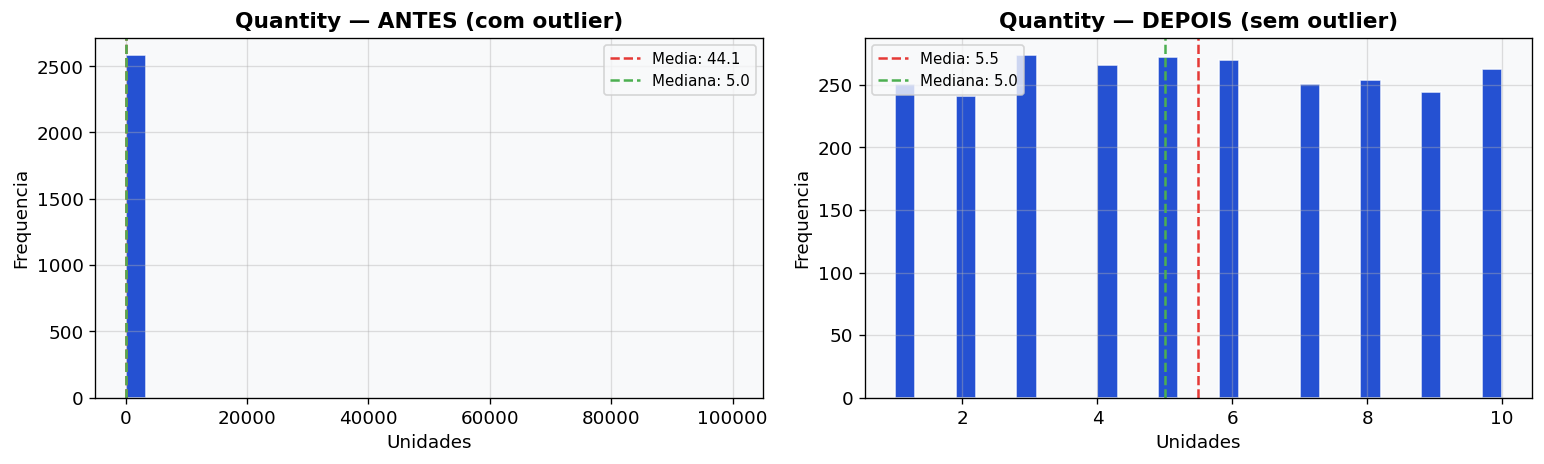

In [96]:
# Validação pelo tipo de negócio
#
#   Produto: Home and lifestyle | Preco unitario: $200
#   Quantidade: 100.000 unidades -> total: $21.000.000
#   Maior transacao legitima na base: 10 unidades ($2.100)
#   Conclusao: impossivel em operacao de varejo de porte medio.
#             Erro de digitacao — 10 virou 100000.
#
# Estratégia: remover apenas este registro.
# Não usar threshold fixo (ex: quantity >= 100) para não diminuir a base desnecessariamente

outlier_mask = mask_iqr | mask_zscore  # equivalentes neste dataset

df = df_sales[~outlier_mask].copy().reset_index(drop=True)

rev_antes  = df_sales['total'].sum()
rev_depois = df['total'].sum()

print('Impacto da remocao:')
print(f'  Linhas originais        : {len(df_sales):,}')
print(f'  Outliers removidos      : {outlier_mask.sum()}')
print(f'  Linhas resultantes      : {len(df):,}')
print(f'  Faturamento original    : ${rev_antes:,.2f}')
print(f'  Faturamento sem outlier : ${rev_depois:,.2f}')
print(f'  Diferenca               : ${rev_antes - rev_depois:,.2f} ({(rev_antes-rev_depois)/rev_antes:.2%} do total)')
print()
print('Estatisticas de quantidade antes da limpeza:')
print(df_sales['quantity'].describe().round(2))
print()
print('Estatisticas de quantidade após limpeza:')
print(df['quantity'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, title in zip(
    axes,
    [df_sales['quantity'], df['quantity']],
    ['Quantity — ANTES (com outlier)', 'Quantity — DEPOIS (sem outlier)']
):
    ax.hist(data, bins=30, color=COLORS['blue'], edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel('Unidades')
    ax.set_ylabel('Frequencia')
    ax.axvline(data.mean(),   color=COLORS['red'],   linestyle='--', label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color=COLORS['green'],  linestyle='--', label=f'Mediana: {data.median():.1f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_outlier_02_comparativo.png', bbox_inches='tight')
plt.show()


### 3.4 Análise e tratamento de duplicatas

In [97]:
# verificando a existência de registros duplicados
print(f'Linhas duplicadas (invoice_id): {df.duplicated(subset="invoice_id").sum()}')
print(f'Linhas duplicadas (todas colunas): {df.duplicated().sum()}')

Linhas duplicadas (invoice_id): 0
Linhas duplicadas (todas colunas): 0


### 3.5 Enriquecimento do df_customers

In [98]:
# join com customer_base 
df = df.merge(df_customers, on='customer_id', how='left', suffixes=('', '_cust'))

# tratando conflito da coluna de genero
if 'gender_cust' in df.columns:
    df.drop(columns=['gender_cust'], inplace=True)

print('Colunas após enriquecimento:')
print(df.columns.tolist())
print(f'\nCobertura customer_base: {df["age"].notna().mean():.1%} dos registros têm perfil cadastral')

Colunas após enriquecimento:
['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax', 'total', 'date', 'time', 'payment', 'cogs', 'gross_margin_pct', 'gross_income', 'rating', 'customer_id', 'Year', 'Month', 'Month_Name', 'Quarter', 'Weekday', 'age', 'annual_income', 'social_class']

Cobertura customer_base: 100.0% dos registros têm perfil cadastral


### 3.6 Resumo do df limpo

In [99]:
print('--- BASE LIMPA: RESUMO ---')
print(f'Período             : {df["date"].min().date()} a {df["date"].max().date()}')
print(f'Transações          : {len(df):,}')
print(f'Clientes distintos  : {df["customer_id"].nunique():,}')
print(f'Linhas de produto   : {df["product_line"].nunique()} — {sorted(df["product_line"].unique())}')
print(f'Filiais             : {sorted(df["branch"].unique())}')
print(f'Faturamento total   : ${df["total"].sum():,.2f}')
display(df.describe(include='all').T[['count','mean','min','max']])

--- BASE LIMPA: RESUMO ---
Período             : 2021-01-01 a 2025-12-25
Transações          : 2,586
Clientes distintos  : 1,211
Linhas de produto   : 6 — ['Electronic accessories', 'Fashion accessories', 'Food and beverages', 'Health and beauty', 'Home and lifestyle', 'Sports and travel']
Filiais             : ['A', 'B', 'C']
Faturamento total   : $1,606,809.45


,count,mean,min,max
invoice_id,2586,NaN,NaN,NaN
branch,2586,NaN,NaN,NaN
city,2586,NaN,NaN,NaN
customer_type,2586,NaN,NaN,NaN
gender,2586,NaN,NaN,NaN
product_line,2586,NaN,NaN,NaN
unit_price,2586.0,107.782289,15.0,200.0
quantity,2586.0,5.49652,1.0,10.0
tax,2586.0,0.047889,0.035,0.05
total,2586.0,621.349362,15.525,2100.0


---
## 4. Análise Exploratória Geral

### 4.1 Faturamento e transações por ano

,Year,receita,gross_income,transacoes,ticket_medio,yoy_growth
0,2021,331091.25,15766.25,534,620.02,NaN
1,2022,182306.25,8681.25,305,597.73,-44.94
2,2023,298032.00,14192.00,452,659.36,63.48
3,2024,350962.50,16712.50,559,627.84,17.76
4,2025,444417.45,18227.45,736,603.83,26.63


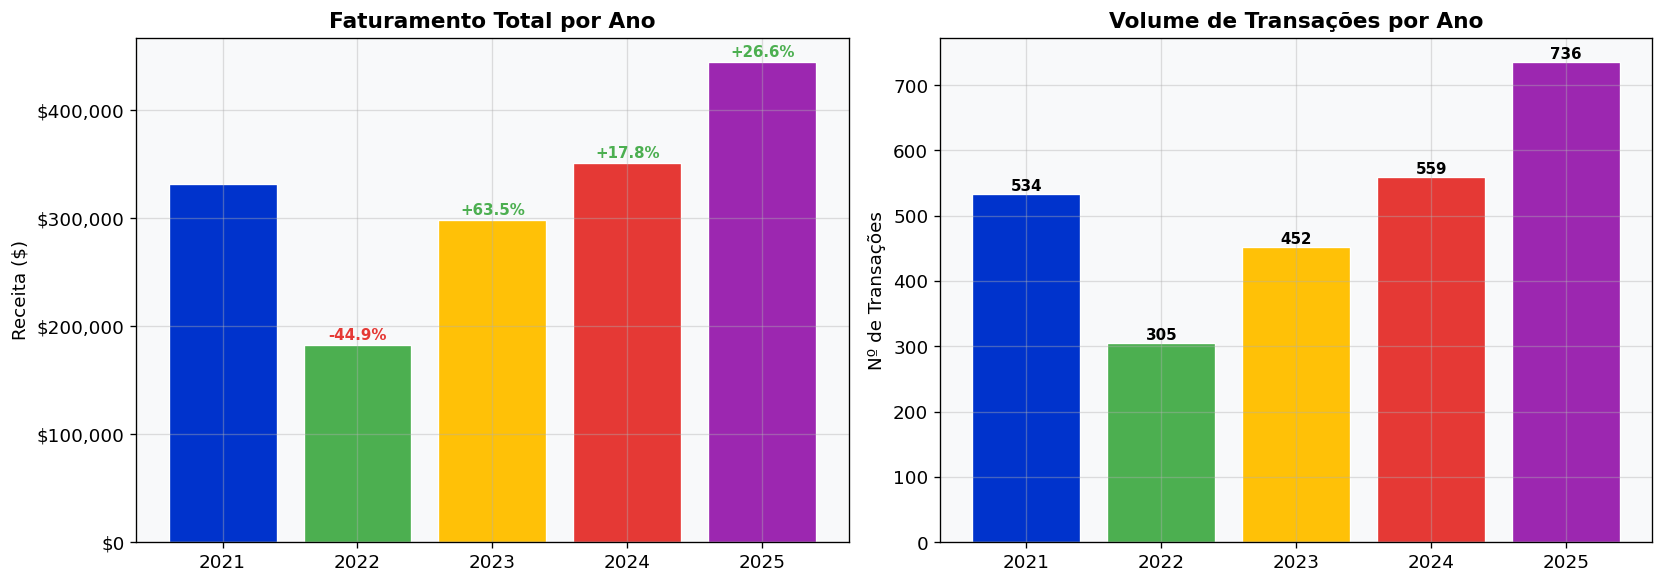

In [100]:
# agregação anual
yearly = df.groupby('Year').agg(
    receita=('total', 'sum'),
    gross_income=('gross_income', 'sum'),
    transacoes=('invoice_id', 'count'),
    ticket_medio=('total', 'mean'),
).reset_index()

yearly['yoy_growth'] = yearly['receita'].pct_change() * 100
display(yearly.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# visualização do faturamento anual
bars = axes[0].bar(yearly['Year'], yearly['receita'], color=PALETTE, edgecolor='white', linewidth=0.8)
axes[0].set_title('Faturamento Total por Ano')
axes[0].set_ylabel('Receita ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, growth in zip(bars[1:], yearly['yoy_growth'].dropna()):
    color = COLORS['green'] if growth > 0 else COLORS['red']
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{growth:+.1f}%', ha='center', va='bottom', fontsize=9, color=color, fontweight='bold')

# visualização do volume de transações anual
axes[1].bar(yearly['Year'], yearly['transacoes'], color=PALETTE, edgecolor='white', linewidth=0.8)
axes[1].set_title('Volume de Transações por Ano')
axes[1].set_ylabel('Nº de Transações')
for i, (year, val) in enumerate(zip(yearly['Year'], yearly['transacoes'])):
    axes[1].text(year, val + 5, str(val), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_01_faturamento_ano.png', bbox_inches='tight')
plt.show()

### 4.2 Distribuição por linha de produto

,product_line,receita,gross_income,transacoes,ticket_medio,rating_medio,gross_margin_pct
4,Home and lifestyle,506289.00,23089.00,443,1142.86,6.95,6.01
5,Sports and travel,458395.20,20995.20,443,1034.75,6.85,15.04
1,Fashion accessories,354373.20,16213.20,503,704.52,6.93,18.09
3,Health and beauty,180420.75,8430.75,347,519.94,6.79,12.06
0,Electronic accessories,68913.90,3123.90,403,171.00,6.84,12.42
2,Food and beverages,38417.40,1727.40,447,85.94,6.99,2.06


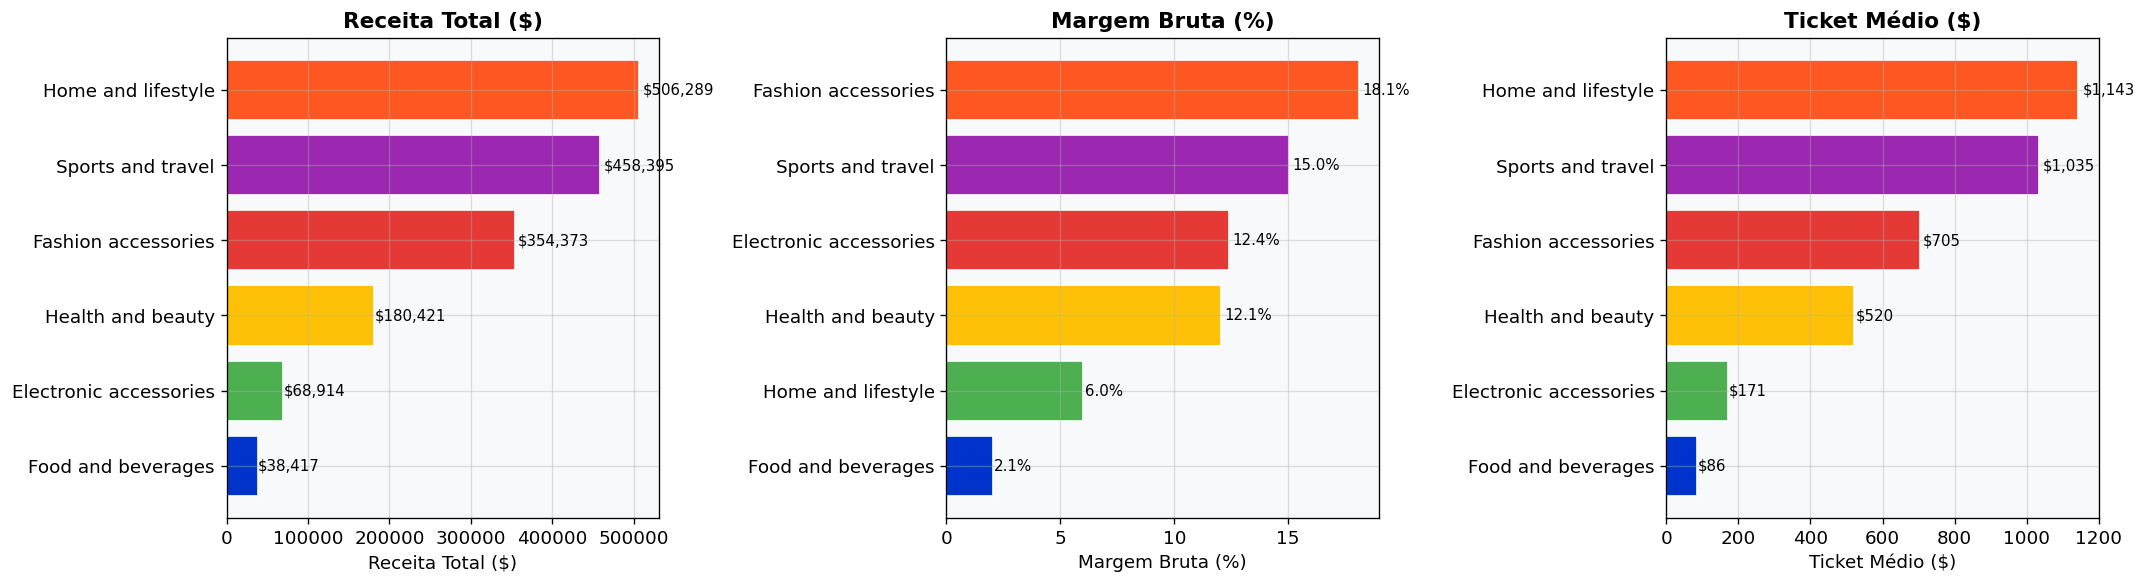

In [101]:
# agregação por linha de produto
pl_summary = df.groupby('product_line').agg(
    receita=('total', 'sum'),
    gross_income=('gross_income', 'sum'),
    transacoes=('invoice_id', 'count'),
    ticket_medio=('total', 'mean'),
    rating_medio=('rating', 'mean'),
).reset_index().merge(df_products[['product_line','gross_margin_pct']], on='product_line', how='left')

pl_summary = pl_summary.sort_values('receita', ascending=False)
display(pl_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# visualização por linha de produto
for ax, col, label in zip(axes,
                           ['receita', 'gross_margin_pct', 'ticket_medio'],
                           ['Receita Total ($)', 'Margem Bruta (%)', 'Ticket Médio ($)']):
    data_sorted = pl_summary.sort_values(col)
    bars = ax.barh(data_sorted['product_line'], data_sorted[col],
                   color=PALETTE[:len(data_sorted)], edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel(label)
    for bar in bars:
        val = bar.get_width()
        fmt = f'{val:.1f}%' if 'Margem' in label else f'${val:,.0f}'
        ax.text(val * 1.01, bar.get_y() + bar.get_height()/2, fmt,
                va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_02_product_line.png', bbox_inches='tight')
plt.show()

### 4.3 Distribuição por método de pagamento ao longo dos anos

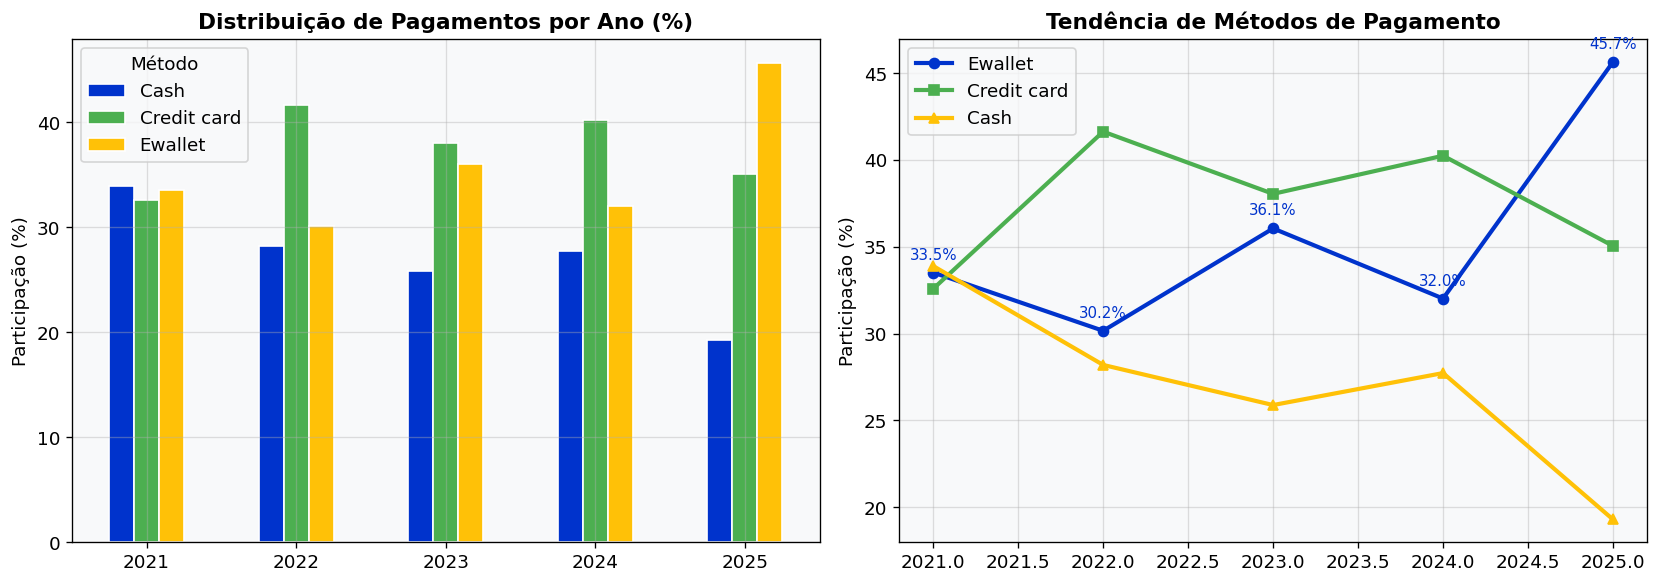

In [102]:
# agregação de métodos de pagamento por ano
pay_year = df.groupby(['Year','payment']).size().unstack(fill_value=0)
pay_pct = pay_year.div(pay_year.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pay_pct.plot(kind='bar', ax=axes[0], color=PALETTE[:3], edgecolor='white')
axes[0].set_title('Distribuição de Pagamentos por Ano (%)')
axes[0].set_ylabel('Participação (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Método')

# linha de tendência para cada método de pagamento
ewallet_pct = pay_pct['Ewallet'] if 'Ewallet' in pay_pct.columns else pay_pct.get('ewallet', pd.Series())
axes[1].plot(pay_pct.index, pay_pct['Ewallet'], marker='o', linewidth=2.5,
             color=COLORS['blue'], label='Ewallet')
axes[1].plot(pay_pct.index, pay_pct['Credit card'], marker='s', linewidth=2.5,
             color=COLORS['green'], label='Credit card')
axes[1].plot(pay_pct.index, pay_pct['Cash'], marker='^', linewidth=2.5,
             color=COLORS['yellow'], label='Cash')
axes[1].set_title('Tendência de Métodos de Pagamento')
axes[1].set_ylabel('Participação (%)')
axes[1].legend()
for year, val in zip(pay_pct.index, pay_pct['Ewallet']):
    axes[1].annotate(f'{val:.1f}%', (year, val), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9, color=COLORS['blue'])

plt.tight_layout()
plt.savefig('fig_03_pagamentos.png', bbox_inches='tight')
plt.show()

### 4.4 Distribuição por perfil dos clientes

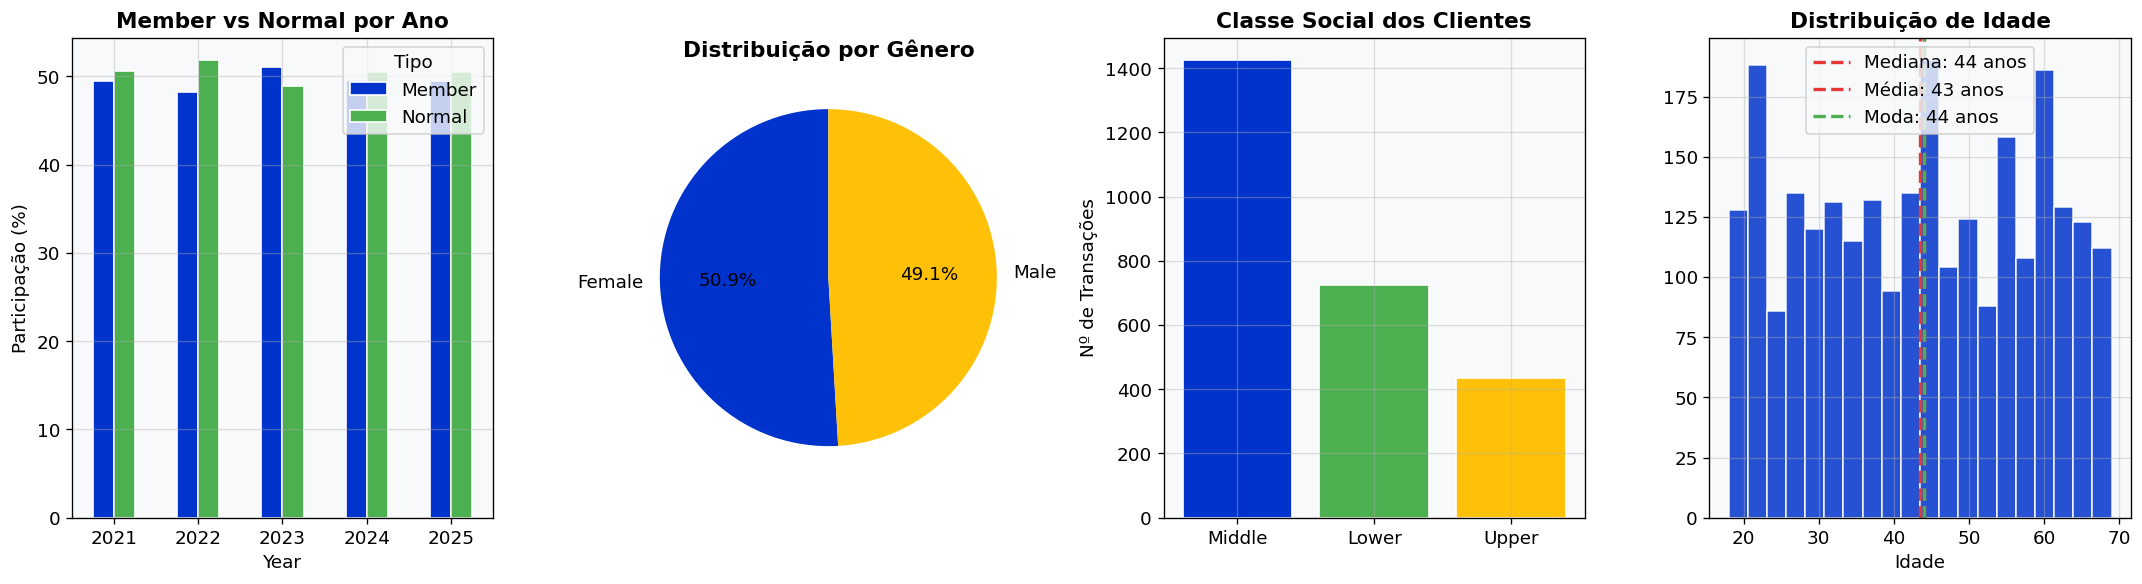

In [103]:
# perfil dos clientes
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# tipo de cliente por ano
ct_year = df.groupby(['Year','customer_type']).size().unstack(fill_value=0)
ct_pct = ct_year.div(ct_year.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=axes[0], color=[COLORS['blue'], COLORS['green']], edgecolor='white')
axes[0].set_title('Member vs Normal por Ano')
axes[0].set_ylabel('Participação (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Tipo')

# gênero
g_counts = df['gender'].value_counts()
axes[1].pie(g_counts.values, labels=g_counts.index, autopct='%1.1f%%',
            colors=[COLORS['blue'], COLORS['yellow']], startangle=90)
axes[1].set_title('Distribuição por Gênero')

# classe
sc = df.dropna(subset=['social_class'])['social_class'].value_counts()
axes[2].bar(sc.index, sc.values, color=PALETTE[:len(sc)], edgecolor='white')
axes[2].set_title('Classe Social dos Clientes')
axes[2].set_ylabel('Nº de Transações')

# idade
df.dropna(subset=['age'])['age'].hist(bins=20, ax=axes[3],
                                      color=COLORS['blue'], edgecolor='white', alpha=0.85)
axes[3].axvline(df['age'].median(), color=COLORS['red'], linestyle='--', linewidth=2,
                label=f'Mediana: {df["age"].median():.0f} anos')
axes[3].axvline(df['age'].mean(), color=COLORS['red'], linestyle='--', linewidth=2,
                label=f'Média: {df["age"].mean():.0f} anos')
axes[3].axvline(df['age'].mode()[0], color=COLORS['green'], linestyle='--', linewidth=2,
                label=f'Moda: {df["age"].mode()[0]:.0f} anos')
axes[3].set_title('Distribuição de Idade')
axes[3].set_xlabel('Idade')
axes[3].legend()

plt.tight_layout()
plt.savefig('fig_04_perfil_clientes.png', bbox_inches='tight')
plt.show()

---
## 5. Q1–3: Satisfação do Cliente com Produtos

### 5.1 Distribuição do rating (nota) por linha de produto e ano

Rating médio por categoria e ano:


product_line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel,Média Geral
Year,,,,,,,
2021,6.77,6.93,6.93,7.10,6.76,6.67,6.86
2022,6.72,6.84,7.00,6.81,7.06,6.92,6.89
2023,6.58,7.33,7.23,6.93,7.22,6.96,7.05
2024,6.64,6.89,7.06,6.52,6.93,6.67,6.78
2025,7.22,6.79,6.89,6.53,6.89,7.01,6.92


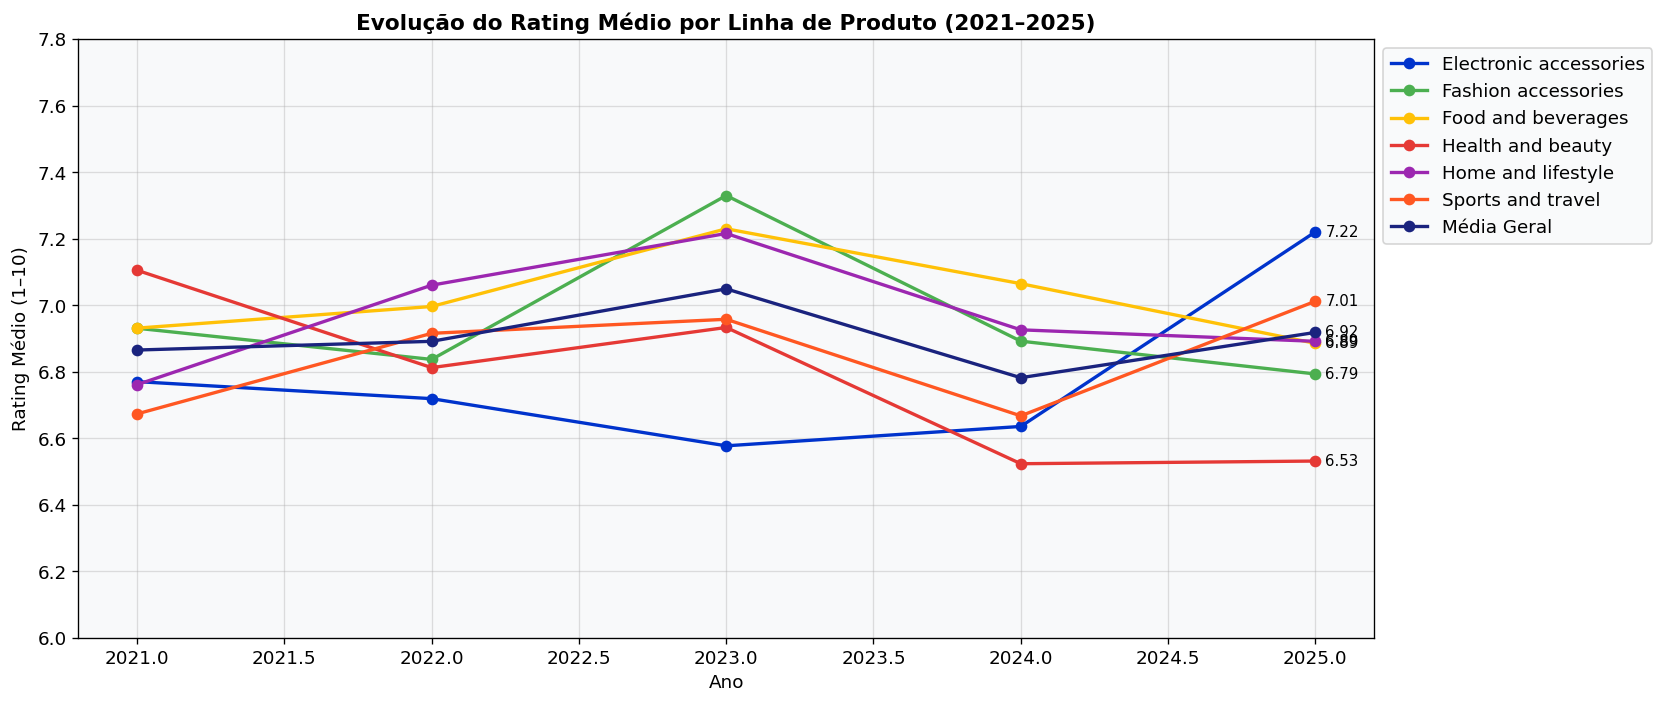

In [104]:
# agregação de rating médio por linha de produto e ano
rating_pl_year = df.groupby(['Year','product_line'])['rating'].mean().unstack()

# média geral por ano (sem segmentação por linha de produto)
rating_year = df.groupby('Year')['rating'].mean()

# adicionando a média geral ao dataframe de rating por linha de produto
rating_pl_year['Média Geral'] = rating_year

print('Rating médio por categoria e ano:')
display(rating_pl_year.round(2))

fig, ax = plt.subplots(figsize=(14, 6))
for i, col in enumerate(rating_pl_year.columns):
    ax.plot(rating_pl_year.index, rating_pl_year[col], marker='o',
            linewidth=2, label=col, color=PALETTE[i % len(PALETTE)])
    # marcando o último valor de cada linha de produto
    last_val = rating_pl_year[col].iloc[-1]
    ax.annotate(f'{last_val:.2f}', (2025, last_val),
                textcoords='offset points', xytext=(6, 0), va='center', fontsize=9)

ax.set_title('Evolução do Rating Médio por Linha de Produto (2021–2025)')
ax.set_ylabel('Rating Médio (1–10)')
ax.set_xlabel('Ano')
ax.set_ylim(6.0, 7.8)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('fig_05_rating_evolucao.png', bbox_inches='tight')
plt.show()

### 5.2 Variação (delta) de rating entre 2021 e 2025

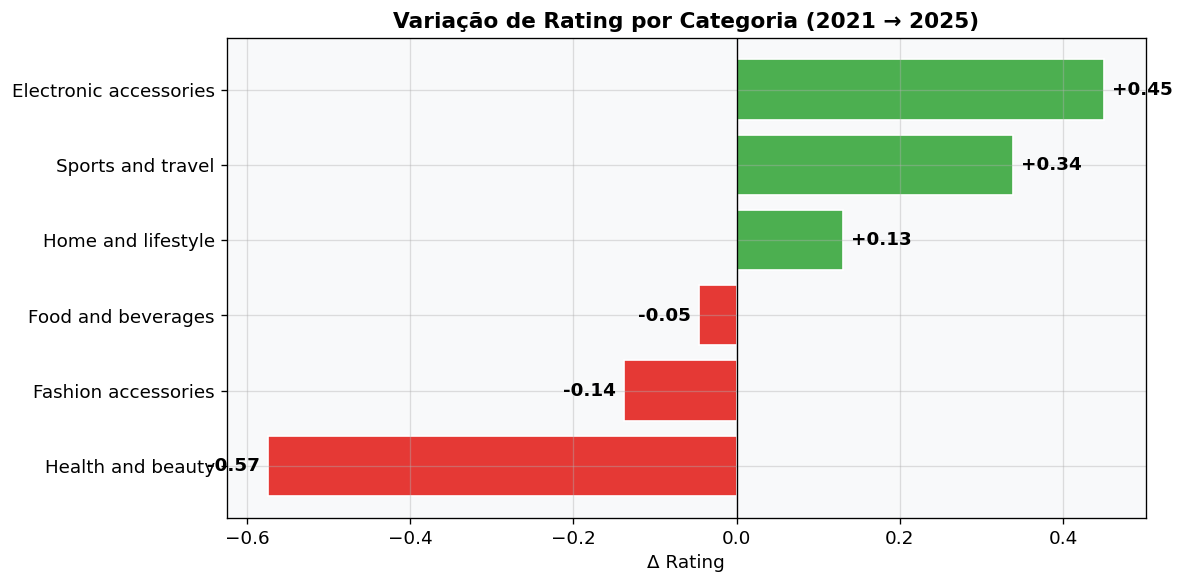

In [105]:
rating_2021 = df[df['Year']==2021].groupby('product_line')['rating'].mean()
rating_2025 = df[df['Year']==2025].groupby('product_line')['rating'].mean()
rating_delta = (rating_2025 - rating_2021).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS['green'] if v > 0 else COLORS['red'] for v in rating_delta.values]
bars = ax.barh(rating_delta.index, rating_delta.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Variação de Rating por Categoria (2021 → 2025)')
ax.set_xlabel('Δ Rating')
for bar in bars:
    val = bar.get_width()
    ax.text(val + (0.01 if val >= 0 else -0.01),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_06_rating_delta.png', bbox_inches='tight')
plt.show()

### 5.3 Margem Bruta x Rating

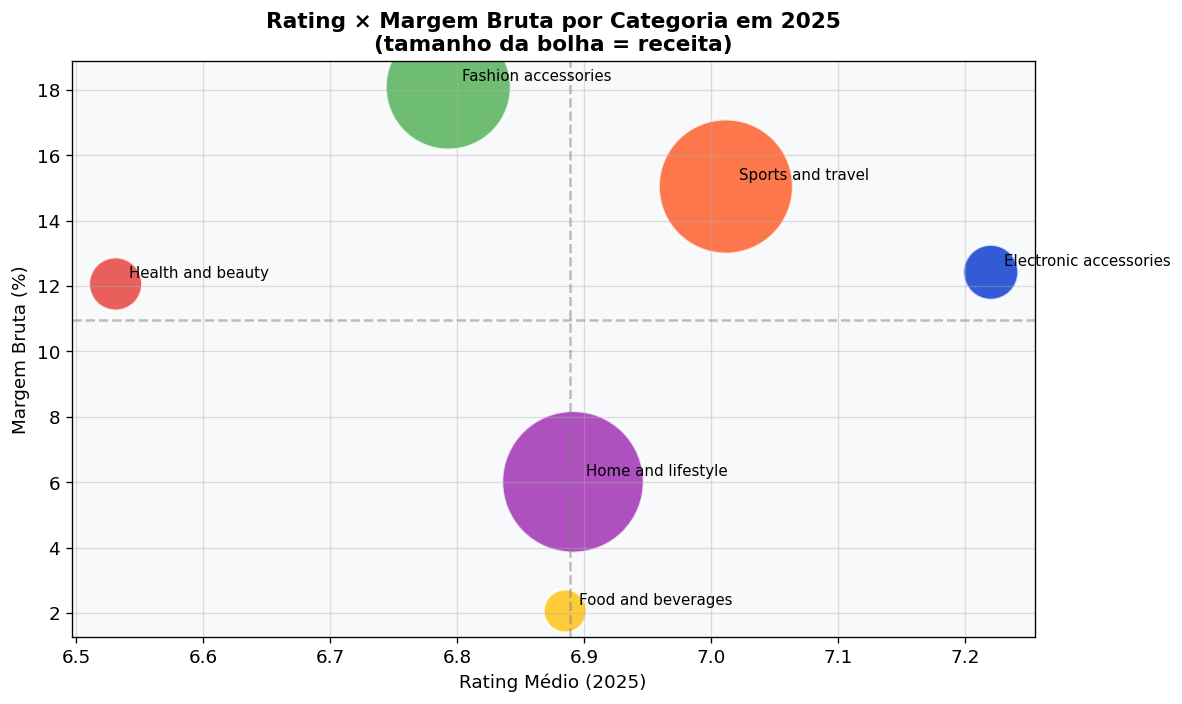

In [106]:
# agregação para gráfico de bolhas
bubble = df[df['Year']==2025].groupby('product_line').agg(
    rating=('rating','mean'),
    receita=('total','sum'),
    transacoes=('invoice_id','count')
).reset_index().merge(df_products[['product_line','gross_margin_pct']], on='product_line')

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    bubble['rating'],
    bubble['gross_margin_pct'],
    s=bubble['receita'] / 20,
    c=PALETTE[:len(bubble)],
    alpha=0.8,
    edgecolors='white',
    linewidth=1.5
)
for _, row in bubble.iterrows():
    ax.annotate(row['product_line'],
                (row['rating'], row['gross_margin_pct']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('Rating Médio (2025)')
ax.set_ylabel('Margem Bruta (%)')
ax.set_title('Rating × Margem Bruta por Categoria em 2025\n(tamanho da bolha = receita)')
ax.axhline(bubble['gross_margin_pct'].mean(), color='gray', linestyle='--', alpha=0.5)
ax.axvline(bubble['rating'].mean(), color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig_07_bubble_rating_margem.png', bbox_inches='tight')
plt.show()

---
## 6. Q4–5: Campanha para Home and Lifestyle

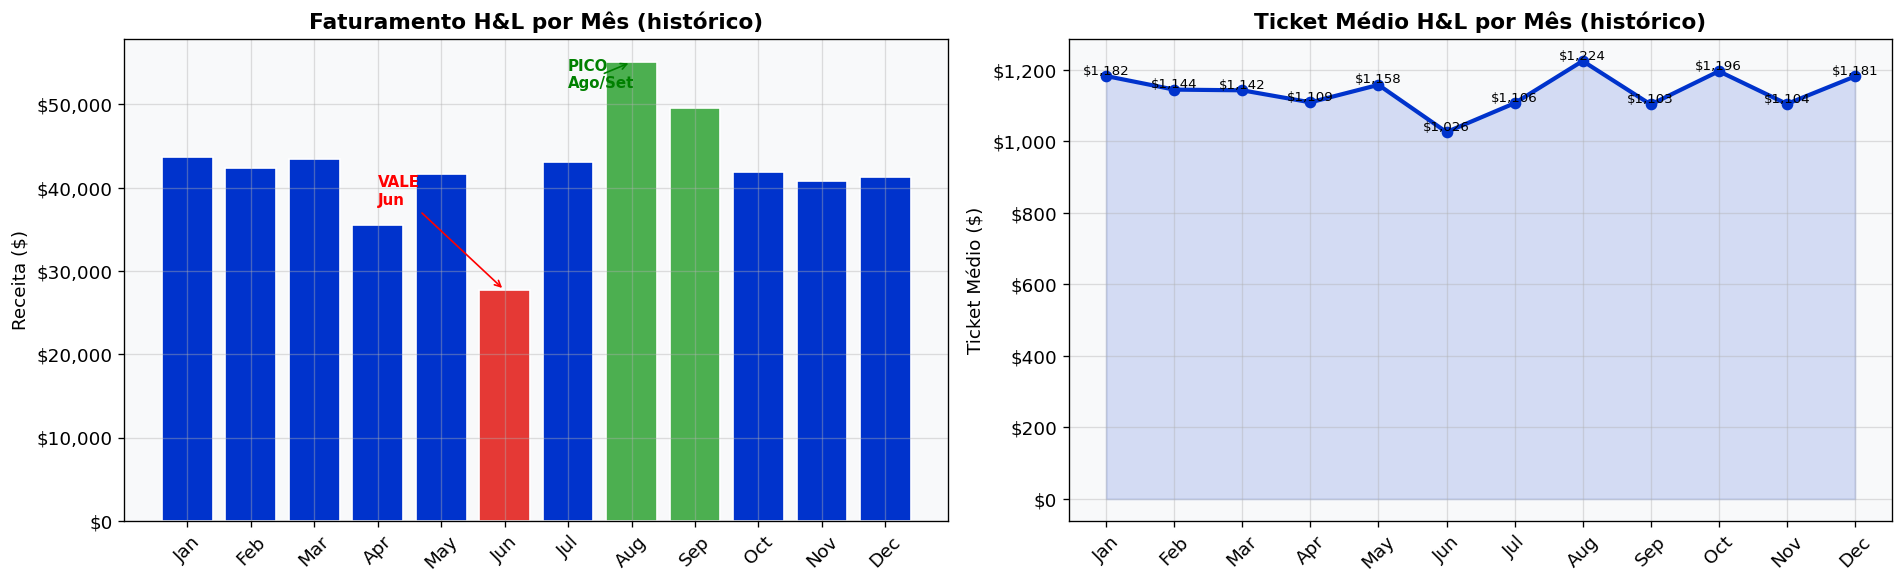

In [107]:
# sazonalidade mensal para Home and Lifestyle (todos os anos)
hl = df[df['product_line'] == 'Home and lifestyle'].copy()

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
hl['Month_Abbr'] = hl['Month'].map(month_map)

hl_monthly = hl.groupby('Month').agg(
    receita=('total','sum'),
    transacoes=('invoice_id','count'),
    ticket_medio=('total','mean')
).reset_index()
hl_monthly['Month_Abbr'] = hl_monthly['Month'].map(month_map)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# receita mensal
bar_colors = [COLORS['red'] if m == 6 else
              (COLORS['green'] if m in [8, 9] else COLORS['blue'])
              for m in hl_monthly['Month']]
axes[0].bar(hl_monthly['Month_Abbr'], hl_monthly['receita'],
            color=bar_colors, edgecolor='white')
axes[0].set_title('Faturamento H&L por Mês (histórico)')
axes[0].set_ylabel('Receita ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].annotate('PICO\nAgo/Set', xy=(7, hl_monthly.loc[hl_monthly['Month']==8,'receita'].values[0]),
                 xytext=(6, 52000), arrowprops=dict(arrowstyle='->', color='green'),
                 color='green', fontweight='bold', fontsize=9)
axes[0].annotate('VALE\nJun', xy=(5, hl_monthly.loc[hl_monthly['Month']==6,'receita'].values[0]),
                 xytext=(3, 38000), arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontweight='bold', fontsize=9)

# ticket médio
axes[1].plot(hl_monthly['Month_Abbr'], hl_monthly['ticket_medio'],
             marker='o', linewidth=2.5, color=COLORS['blue'])
axes[1].fill_between(range(len(hl_monthly)), hl_monthly['ticket_medio'],
                     alpha=0.15, color=COLORS['blue'])
axes[1].set_title('Ticket Médio H&L por Mês (histórico)')
axes[1].set_ylabel('Ticket Médio ($)')
axes[1].set_xticks(range(len(hl_monthly)))
axes[1].set_xticklabels(hl_monthly['Month_Abbr'], rotation=45)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, row in hl_monthly.iterrows():
    axes[1].text(i, row['ticket_medio'] + 5, f'${row["ticket_medio"]:,.0f}',
                 ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_08_hl_sazonalidade.png', bbox_inches='tight')
plt.show()

### 6.2 Mapa de calor das vendas de H&L, por mês e ano

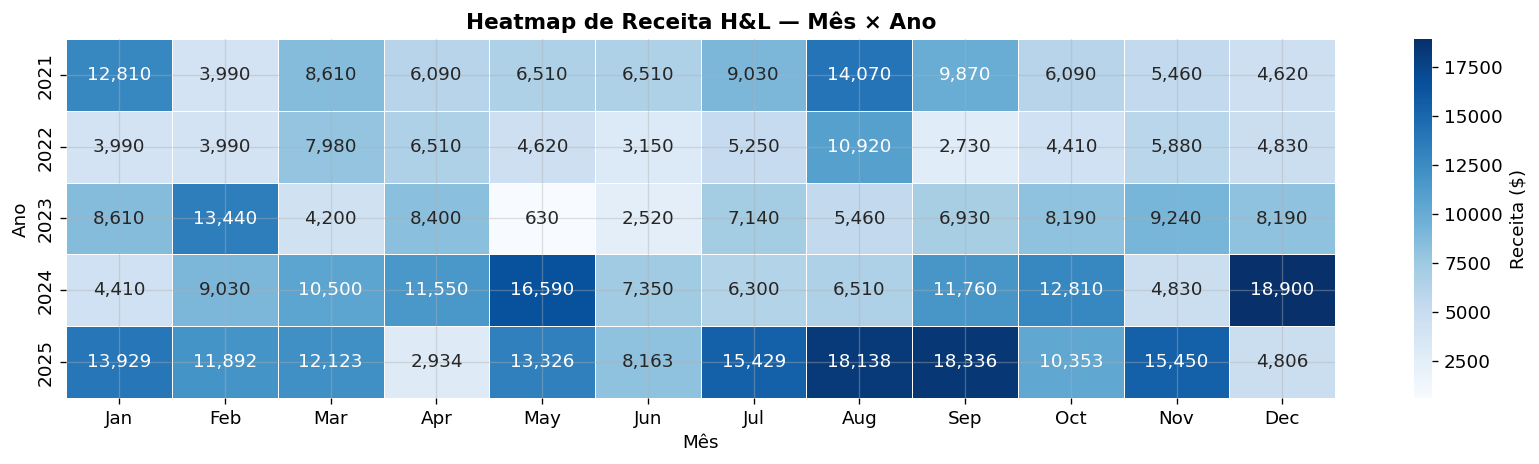

In [108]:
# agregação para o mapa de calor de vendas
hl_pivot = hl.groupby(['Year','Month'])['total'].sum().unstack(fill_value=0)
hl_pivot.columns = [month_map[m] for m in hl_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(hl_pivot, annot=True, fmt=',.0f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Receita ($)'})
ax.set_title('Heatmap de Receita H&L — Mês × Ano')
ax.set_xlabel('Mês')
ax.set_ylabel('Ano')
plt.tight_layout()
plt.savefig('fig_09_hl_heatmap.png', bbox_inches='tight')
plt.show()

### 6.3 Perfil do público de H&L

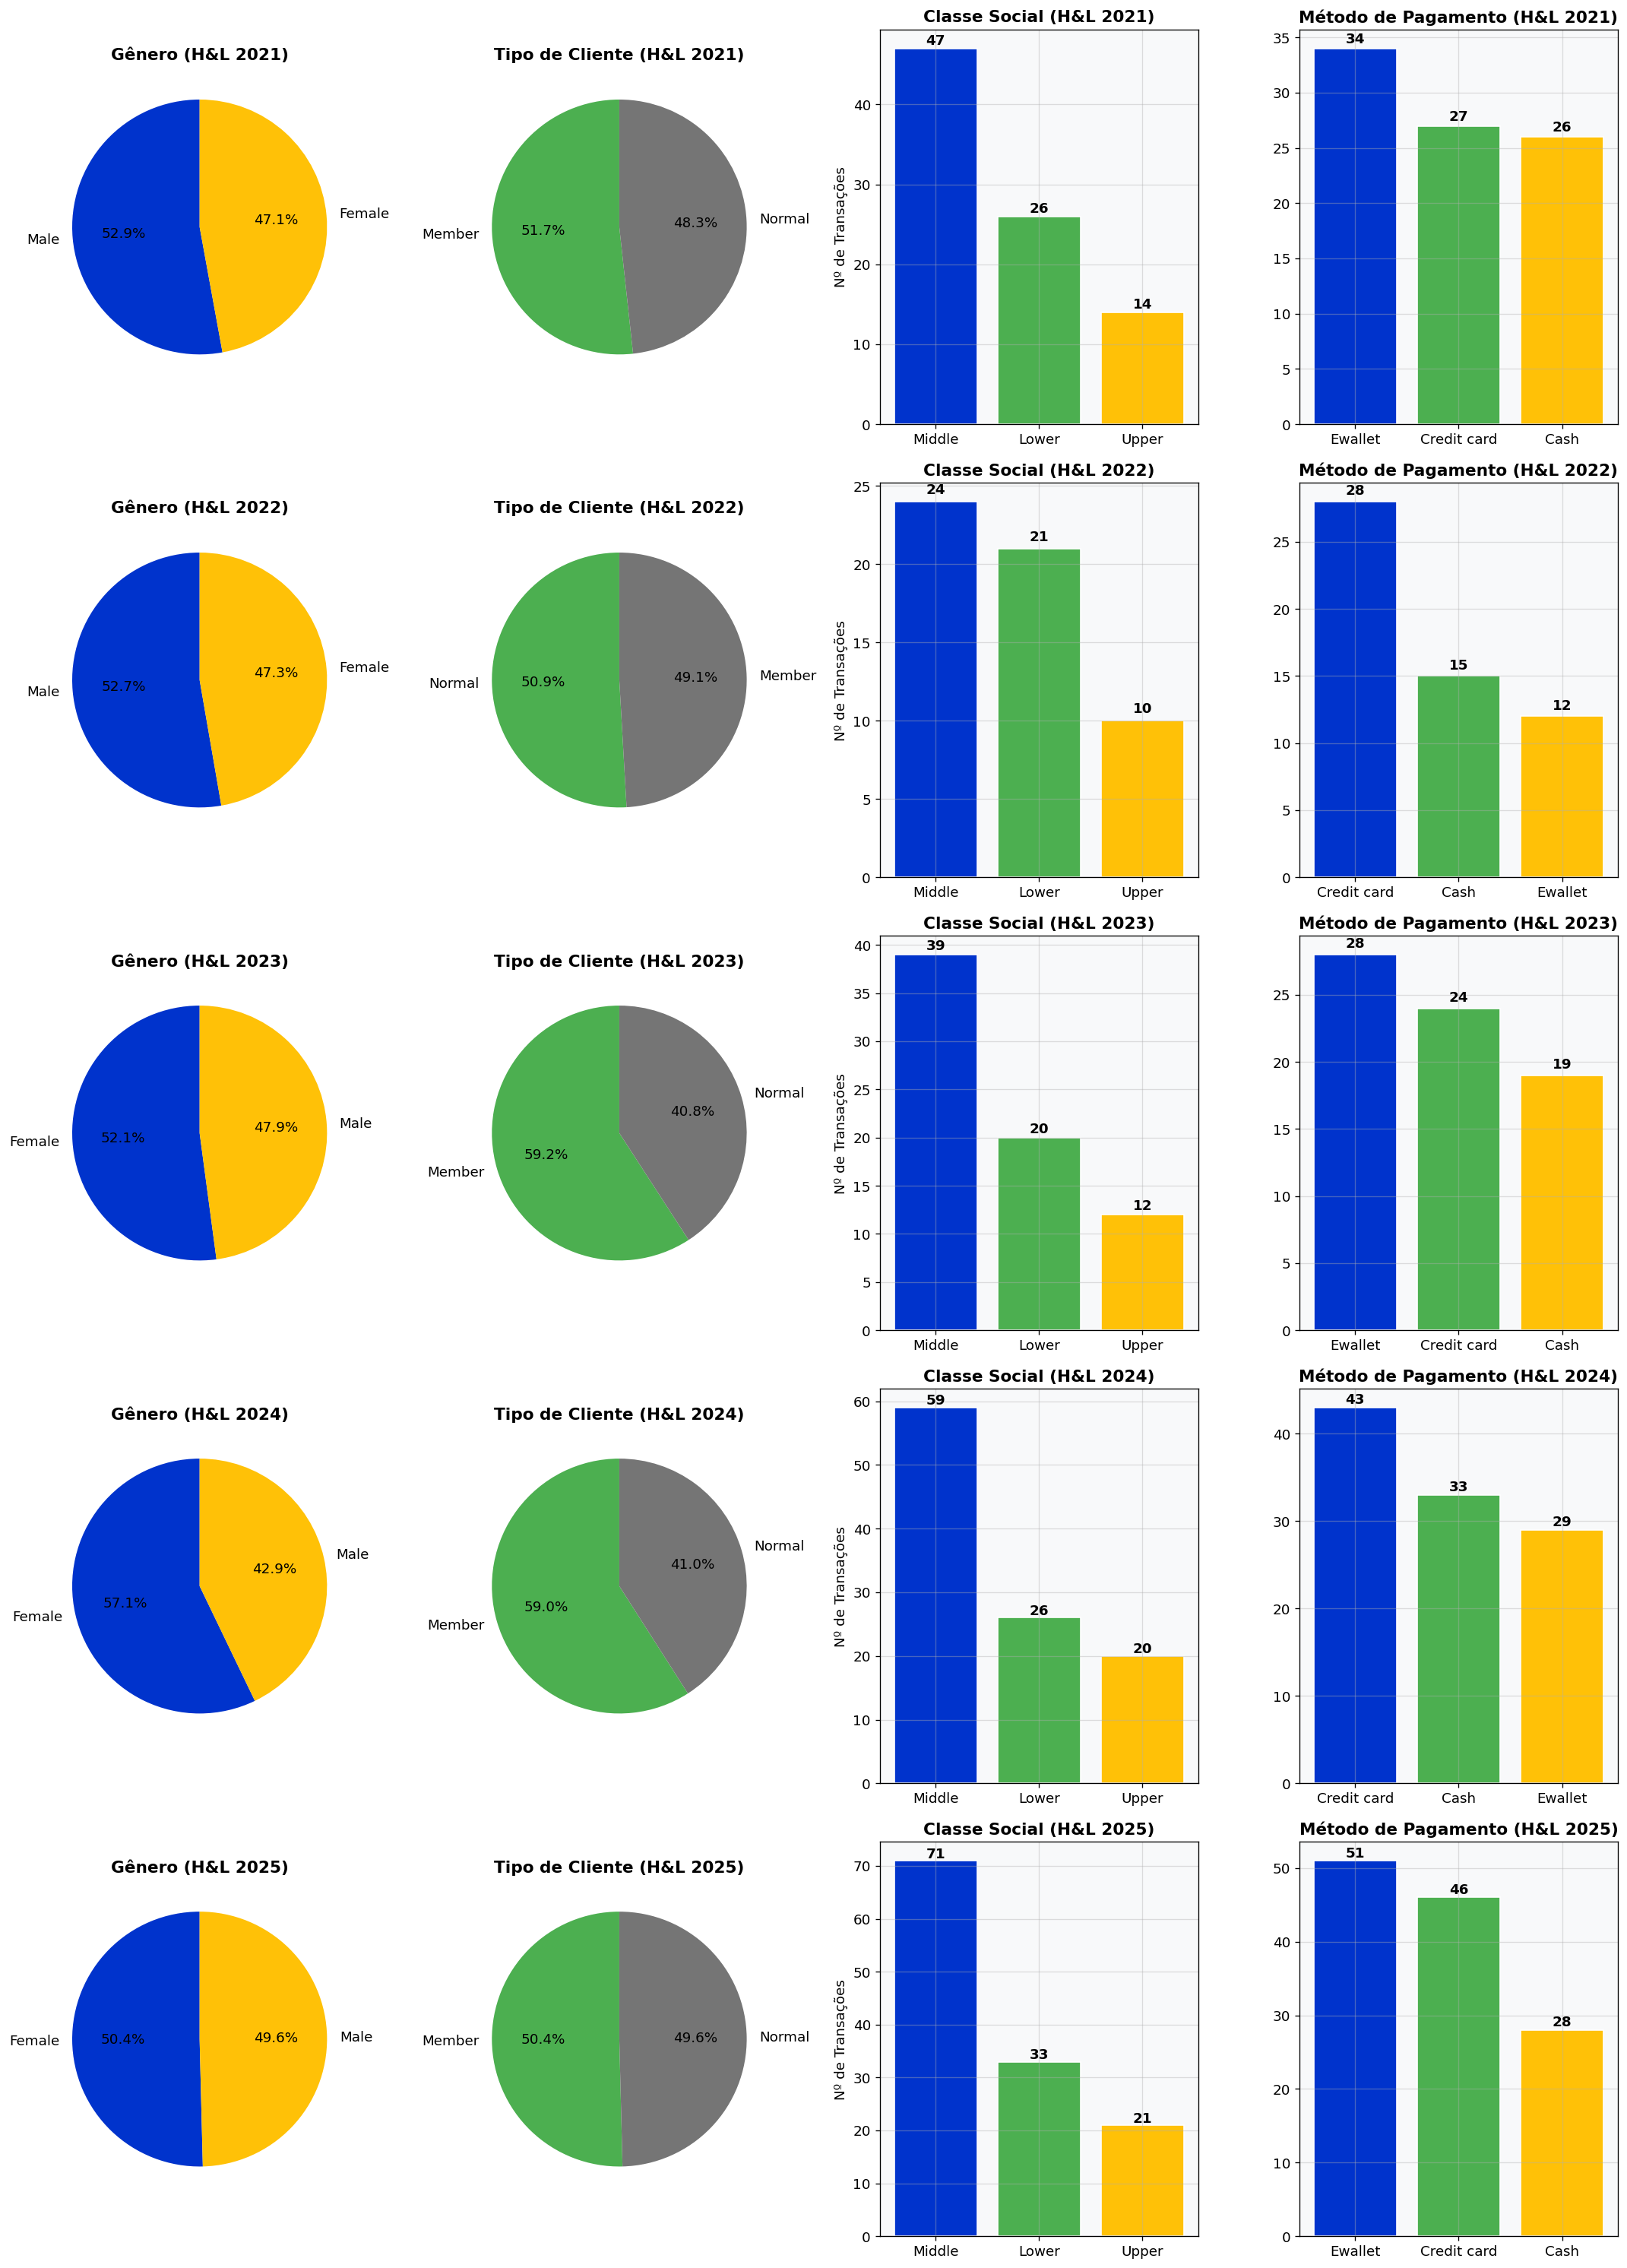


Idade dos clientes H&L 2021:
count    87.0
mean     42.5
std      13.1
min      19.0
25%      33.0
50%      43.0
75%      53.5
max      69.0
Name: age, dtype: float64

Idade dos clientes H&L 2022:
count    55.0
mean     42.7
std      14.0
min      20.0
25%      30.0
50%      43.0
75%      53.5
max      68.0
Name: age, dtype: float64

Idade dos clientes H&L 2023:
count    71.0
mean     45.5
std      15.9
min      18.0
25%      30.5
50%      48.0
75%      59.5
max      69.0
Name: age, dtype: float64

Idade dos clientes H&L 2024:
count    105.0
mean      43.9
std       13.9
min       18.0
25%       36.0
50%       45.0
75%       57.0
max       69.0
Name: age, dtype: float64

Idade dos clientes H&L 2025:
count    125.0
mean      44.9
std       14.3
min       18.0
25%       33.0
50%       44.0
75%       58.0
max       69.0
Name: age, dtype: float64


In [109]:
# filtrando todos os anos
hl_periodo = hl[hl['Year'].between(2021, 2025)]

anos = sorted(hl_periodo['Year'].unique())
fig, axes = plt.subplots(len(anos), 4, figsize=(18, 5 * len(anos)))

for idx, year in enumerate(anos):
    hl_year = hl_periodo[hl_periodo['Year'] == year]

    # genero
    g = hl_year['gender'].value_counts()
    axes[idx, 0].pie(g.values, labels=g.index, autopct='%1.1f%%',
                     colors=[COLORS['blue'], COLORS['yellow']], startangle=90)
    axes[idx, 0].set_title(f'Gênero (H&L {year})')

    # tipo de cliente
    ct = hl_year['customer_type'].value_counts()
    axes[idx, 1].pie(ct.values, labels=ct.index, autopct='%1.1f%%',
                     colors=[COLORS['green'], COLORS['gray']], startangle=90)
    axes[idx, 1].set_title(f'Tipo de Cliente (H&L {year})')

    # classe
    sc = hl_year.dropna(subset=['social_class'])['social_class'].value_counts()
    axes[idx, 2].bar(sc.index, sc.values, color=PALETTE[:len(sc)], edgecolor='white')
    axes[idx, 2].set_title(f'Classe Social (H&L {year})')
    axes[idx, 2].set_ylabel('Nº de Transações')
    for i, v in enumerate(sc.values):
        axes[idx, 2].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    # metodo de pagametno
    pay = hl_year['payment'].value_counts()
    axes[idx, 3].bar(pay.index, pay.values, color=PALETTE[:len(pay)], edgecolor='white')
    axes[idx, 3].set_title(f'Método de Pagamento (H&L {year})')
    for i, v in enumerate(pay.values):
        axes[idx, 3].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_hl_publico_2021_2025.png', bbox_inches='tight')
plt.show()

# estatísticas de idade por ano
for year in anos:
    print(f'\nIdade dos clientes H&L {year}:')
    print(hl_periodo[hl_periodo['Year'] == year]['age'].describe().round(1))

---
## 7. Q6: Orçamento de mkt reduzido: qual produto priorizar?

### 7.1 Método de score composto: margem x ticket x participação na renda bruta

In [110]:
# agregação para score composto
marketing = df.groupby('product_line').agg(
    receita=('total','sum'),
    gross_income=('gross_income','sum'),
    transacoes=('invoice_id','count'),
    ticket_medio=('total','mean'),
    rating=('rating','mean')
).reset_index().merge(df_products[['product_line','gross_margin_pct']], on='product_line')

total_gi = marketing['gross_income'].sum()
marketing['gi_share'] = marketing['gross_income'] / total_gi

# score normalizado (0–1 em cada dimensão)
for col in ['ticket_medio', 'gross_margin_pct', 'gi_share', 'transacoes']:
    marketing[f'{col}_norm'] = (marketing[col] - marketing[col].min()) / \
                                (marketing[col].max() - marketing[col].min())

# ponderação: margem 40%, ticket 35%, volume 25% --- testar diferentes pesos para avaliar impacto no ranking final
marketing['score'] = (marketing['gross_margin_pct_norm'] * 0.40 +
                      marketing['ticket_medio_norm'] * 0.35 +
                      marketing['transacoes_norm'] * 0.25)

marketing_sorted = marketing.sort_values('score', ascending=False)
display(marketing_sorted[['product_line','receita','gross_income','gross_margin_pct',
                           'ticket_medio','transacoes','score']].round(3))

,product_line,receita,gross_income,gross_margin_pct,ticket_medio,transacoes,score
1,Fashion accessories,354373.20,16213.20,18.089,704.519,503,0.855
5,Sports and travel,458395.20,20995.20,15.045,1034.752,443,0.792
4,Home and lifestyle,506289.00,23089.00,6.014,1142.865,443,0.602
3,Health and beauty,180420.75,8430.75,12.065,519.945,347,0.393
0,Electronic accessories,68913.90,3123.90,12.423,171.002,403,0.376
2,Food and beverages,38417.40,1727.40,2.064,85.945,447,0.160


### 7.2 Visualização do Score de Marketing

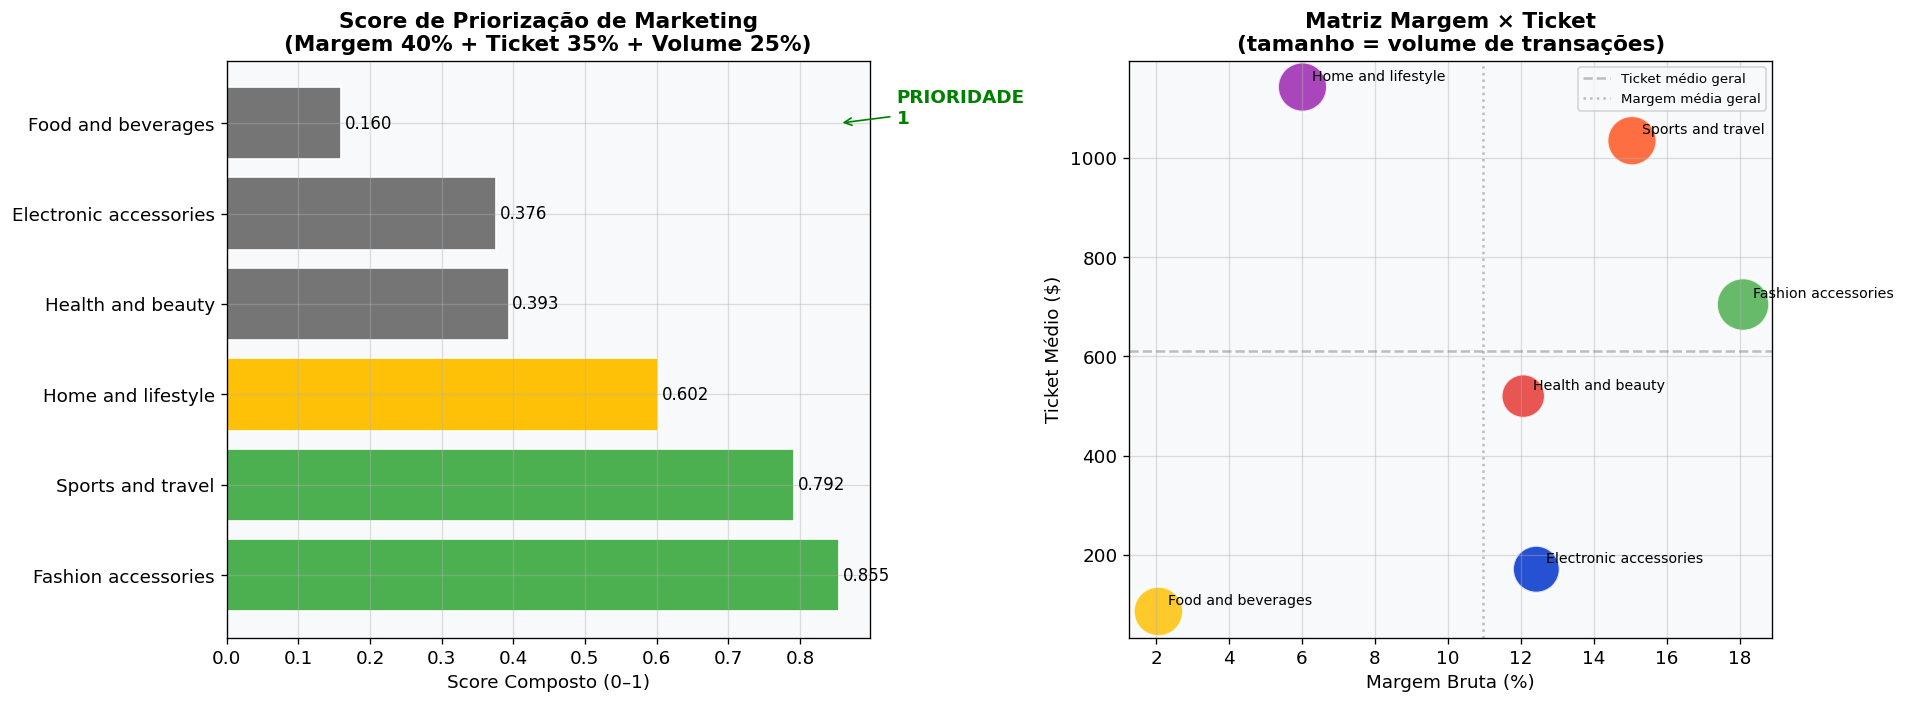

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# score final
ms = marketing_sorted.copy()
bar_colors = [COLORS['green'] if i < 2 else
              (COLORS['yellow'] if i == 2 else COLORS['gray'])
              for i in range(len(ms))]
axes[0].barh(ms['product_line'], ms['score'], color=bar_colors, edgecolor='white')
axes[0].set_title('Score de Priorização de Marketing\n(Margem 40% + Ticket 35% + Volume 25%)')
axes[0].set_xlabel('Score Composto (0–1)')
for i, (_, row) in enumerate(ms.iterrows()):
    axes[0].text(row['score'] + 0.005, i, f'{row["score"]:.3f}', va='center', fontsize=10)
axes[0].annotate('PRIORIDADE\n1', xy=(ms['score'].iloc[0], len(ms)-1),
                 xytext=(ms['score'].iloc[0]+0.08, len(ms)-1),
                 arrowprops=dict(arrowstyle='->', color='green'),
                 color='green', fontweight='bold')

# matrix de margem × tm
sc = axes[1].scatter(
    marketing['gross_margin_pct'],
    marketing['ticket_medio'],
    s=marketing['transacoes'] * 2,
    c=PALETTE[:len(marketing)],
    alpha=0.85,
    edgecolors='white',
    linewidth=1.5
)
for _, row in marketing.iterrows():
    axes[1].annotate(row['product_line'],
                     (row['gross_margin_pct'], row['ticket_medio']),
                     textcoords='offset points', xytext=(6, 4), fontsize=8.5)

axes[1].axhline(marketing['ticket_medio'].mean(), color='gray', linestyle='--', alpha=0.5, label='Ticket médio geral')
axes[1].axvline(marketing['gross_margin_pct'].mean(), color='gray', linestyle=':', alpha=0.5, label='Margem média geral')
axes[1].set_xlabel('Margem Bruta (%)')
axes[1].set_ylabel('Ticket Médio ($)')
axes[1].set_title('Matriz Margem × Ticket\n(tamanho = volume de transações)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('fig_11_marketing_score.png', bbox_inches='tight')
plt.show()

---
## 8. Q7–8: Análise de Clientes Inativos e Campanha de Reativação

### 8.1 Definição de clientes inativos

In [112]:
# definindo como cliente inativo aquele que não realizou nenhuma compra em 2025
active_2025 = set(df[df['Year'] == 2025]['customer_id'].unique())
all_customers = set(df['customer_id'].unique())
inactive_ids = all_customers - active_2025

print(f'Clientes ativos em 2025    : {len(active_2025):,}')
print(f'Clientes inativos em 2025  : {len(inactive_ids):,}')
print(f'Total clientes histórico   : {len(all_customers):,}')
print(f'Taxa de inatividade        : {len(inactive_ids)/len(all_customers):.1%}')

Clientes ativos em 2025    : 736
Clientes inativos em 2025  : 475
Total clientes histórico   : 1,211
Taxa de inatividade        : 39.2%


### 8.2 Última compra dos clientes inativos

Distribuição da última compra dos inativos:
date
2021     58
2022     74
2023    105
2024    238
Name: count, dtype: int64


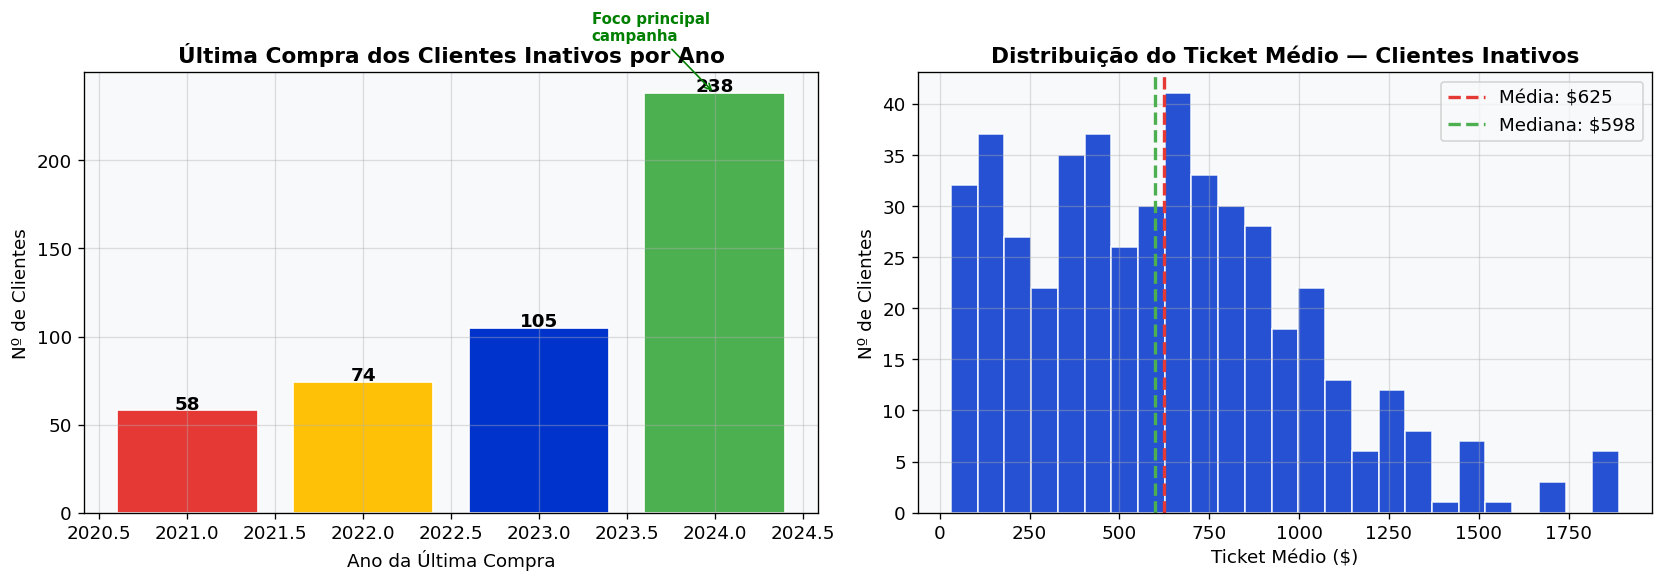

In [113]:
# segmentação por recência (ano da última compra)
last_purchase = df[df['customer_id'].isin(inactive_ids)].groupby('customer_id')['date'].max()
last_purchase_year = last_purchase.dt.year.value_counts().sort_index()

df_inactive = df[df['customer_id'].isin(inactive_ids)].copy()
df_inactive_profile = df_inactive.merge(
    df_customers, on='customer_id', how='left', suffixes=('','_c')
)

print('Distribuição da última compra dos inativos:')
print(last_purchase_year)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribuição por ano da última compra
colors_lpc = [COLORS['red'], COLORS['yellow'], COLORS['blue'], COLORS['green']]
bars = axes[0].bar(last_purchase_year.index, last_purchase_year.values,
                   color=colors_lpc, edgecolor='white')
axes[0].set_title('Última Compra dos Clientes Inativos por Ano')
axes[0].set_ylabel('Nº de Clientes')
axes[0].set_xlabel('Ano da Última Compra')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(int(bar.get_height())), ha='center', fontweight='bold')
axes[0].annotate('Foco principal\ncampanha', xy=(2024, last_purchase_year[2024]),
                 xytext=(2023.3, last_purchase_year[2024] + 30),
                 arrowprops=dict(arrowstyle='->', color='green'),
                 color='green', fontweight='bold', fontsize=9)

# ticket médio histórico dos inativos
inactive_avg_ticket = df_inactive.groupby('customer_id')['total'].mean()
inactive_avg_ticket.hist(bins=25, ax=axes[1], color=COLORS['blue'],
                         edgecolor='white', alpha=0.85)
axes[1].axvline(inactive_avg_ticket.mean(), color=COLORS['red'], linewidth=2,
                linestyle='--', label=f'Média: ${inactive_avg_ticket.mean():,.0f}')
axes[1].axvline(inactive_avg_ticket.median(), color=COLORS['green'], linewidth=2,
                linestyle='--', label=f'Mediana: ${inactive_avg_ticket.median():,.0f}')
axes[1].set_title('Distribuição do Ticket Médio — Clientes Inativos')
axes[1].set_xlabel('Ticket Médio ($)')
axes[1].set_ylabel('Nº de Clientes')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_12_inativos.png', bbox_inches='tight')
plt.show()

### 8.3 Simulação da meta de reativação

In [114]:
avg_ticket_inativos = df_inactive.groupby('customer_id')['total'].mean().mean()
# inativos de 2024 (mais recentes)
inactive_2024_ids = last_purchase[last_purchase.dt.year == 2024].index
avg_ticket_2024 = df_inactive[df_inactive['customer_id'].isin(inactive_2024_ids)]['total'].mean()

meta_faturamento = 30_000

# distintos cenários
cenarios = [
    ('Ticket médio histórico (todos)', avg_ticket_inativos, 0.20),
    ('Ticket médio inativos de 2024', avg_ticket_2024, 0.20),
    ('Ticket médio inativos de 2024 (conv. 25%)', avg_ticket_2024, 0.25),
    ('Ticket médio inativos de 2024 (conv. 15%)', avg_ticket_2024, 0.15),
]

print(f'--- SIMULAÇÃO: META DE ${meta_faturamento:,} ---')
print(f'Total clientes inativos disponíveis: {len(inactive_ids)}')
print(f'Total inativos de 2024 (foco): {len(inactive_2024_ids)}')
print()
print(f'{"Cenário":<50} {"Ticket":<12} {"Conv.":<8} {"Precisam":<12} {"Contatar":<12} {"Receita Proj."}')
print('-' * 110)
for label, ticket, conv in cenarios:
    needed = meta_faturamento / ticket
    to_contact = needed / conv
    proj_full = len(inactive_ids) * conv * ticket
    print(f'{label:<50} ${ticket:<11,.0f} {conv:<8.0%} {needed:<12.0f} {to_contact:<12.0f} ${proj_full:,.0f}')

--- SIMULAÇÃO: META DE $30,000 ---
Total clientes inativos disponíveis: 475
Total inativos de 2024 (foco): 238

Cenário                                            Ticket       Conv.    Precisam     Contatar     Receita Proj.
--------------------------------------------------------------------------------------------------------------
Ticket médio histórico (todos)                     $625         20%      48           240          $59,364
Ticket médio inativos de 2024                      $619         20%      49           243          $58,760
Ticket médio inativos de 2024 (conv. 25%)          $619         25%      49           194          $73,450
Ticket médio inativos de 2024 (conv. 15%)          $619         15%      49           323          $44,070


### 8.4 Perfil dos clientes inativos

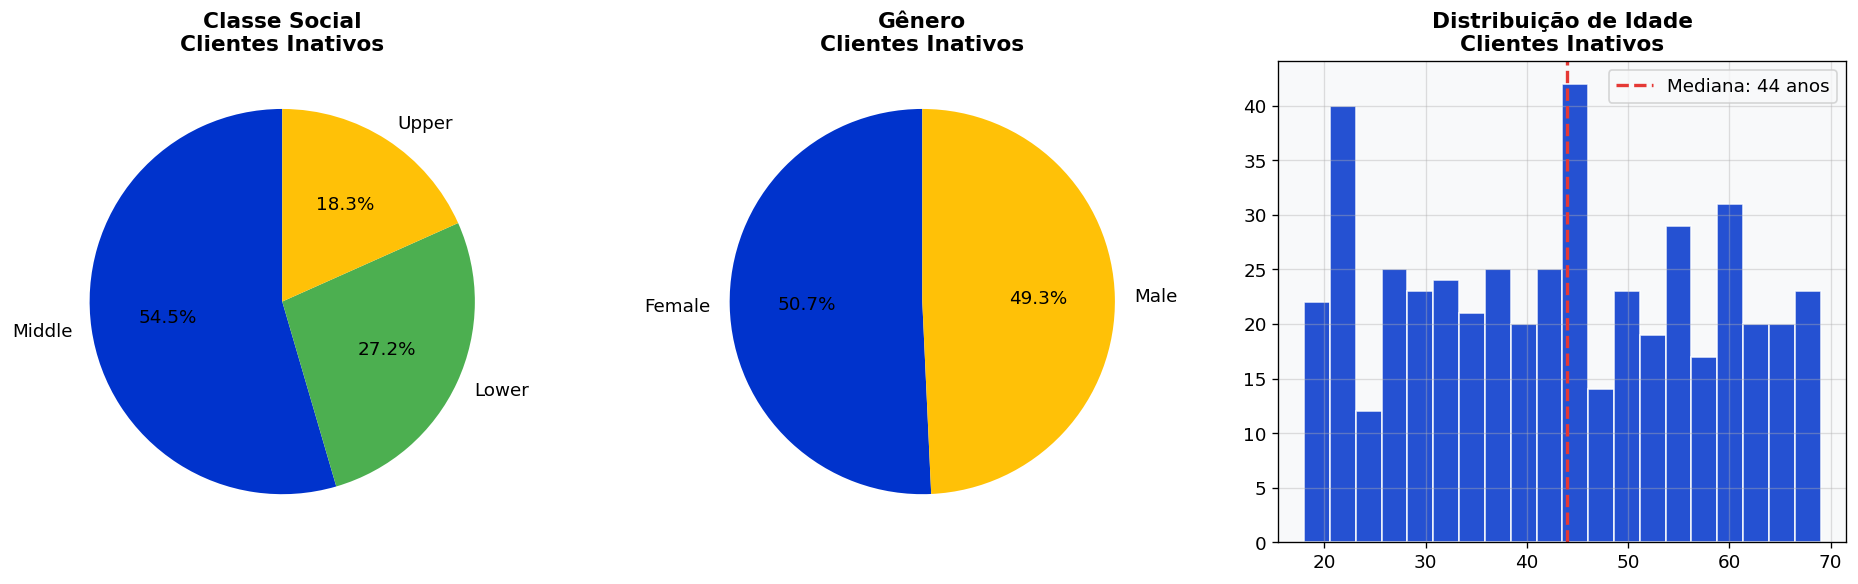

Estatísticas de idade dos inativos:
count    475.0
mean      43.0
std       14.7
min       18.0
25%       30.0
50%       44.0
75%       56.0
max       69.0
Name: age, dtype: float64


In [115]:
# agrupando o perfil dos clientes inativos para análise de segmentação
inactive_customers_profile = df_customers[df_customers['customer_id'].isin(inactive_ids)].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# classe
sc = inactive_customers_profile['social_class'].value_counts()
axes[0].pie(sc.values, labels=sc.index, autopct='%1.1f%%',
            colors=PALETTE[:len(sc)], startangle=90)
axes[0].set_title('Classe Social\nClientes Inativos')

# gênero
g = inactive_customers_profile['gender'].value_counts()
axes[1].pie(g.values, labels=g.index, autopct='%1.1f%%',
            colors=[COLORS['blue'], COLORS['yellow']], startangle=90)
axes[1].set_title('Gênero\nClientes Inativos')

# distribuição de idade
inactive_customers_profile['age'].hist(bins=20, ax=axes[2],
                                        color=COLORS['blue'], edgecolor='white', alpha=0.85)
axes[2].axvline(inactive_customers_profile['age'].median(), color=COLORS['red'],
                linestyle='--', linewidth=2,
                label=f'Mediana: {inactive_customers_profile["age"].median():.0f} anos')
axes[2].set_title('Distribuição de Idade\nClientes Inativos')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig_13_perfil_inativos.png', bbox_inches='tight')
plt.show()

print('Estatísticas de idade dos inativos:')
print(inactive_customers_profile['age'].describe().round(1))

---
## 9. Q9–10: Outros Insights e Estratégias

### 9.1 Análise RFM - Segmentação de Clientes

**RFM (Recência, Frequência, Monetário)** classificar cada cliente em 3 dimensoes (score 1–5 cada) e os agrupar em segmentos com ações específicas

| Dimensão | Definição |
|----------|-----------|
| **R — Recência** | Dias desde a última compra (menor = melhor) |
| **F — Frequência** | Número de transações no período |
| **M — Monetário** | Valor total gasto no período |

In [116]:
# Data de referência: 1 de janeiro de 2026 --- escolhida devido o último registro ser em 2025, facilitando interpretação em dias
DATA_REF = pd.Timestamp('2026-01-01')

rfm = df.groupby('customer_id').agg(
    recencia   = ('date',       lambda x: (DATA_REF - x.max()).days),
    frequencia = ('invoice_id', 'count'),
    monetario  = ('total',      'sum')
).reset_index()

print('Estatísticas RFM (todos os clientes):')
print(rfm[['recencia','frequencia','monetario']].describe().round(2))


Estatísticas RFM (todos os clientes):
       recencia  frequencia  monetario
count   1211.00     1211.00    1211.00
mean     460.03        2.14    1326.85
std      427.48        1.03    1038.61
min        7.00        1.00      15.52
25%      151.00        1.00     441.00
50%      304.00        2.00    1156.05
75%      645.00        3.00    1939.50
max     1808.00        5.00    5544.00


In [117]:
# distribuição de notas por quintis (1=pior, 5=melhor)
# recência: inversão — cliente mais recente recebe nota MAIOR (melhor)
rfm['R'] = pd.qcut(rfm['recencia'],
                    q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequencia'].rank(method='first'),
                    q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetario'],
                    q=5, labels=[1,2,3,4,5]).astype(int)

rfm['rfm_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['rfm_total'] = rfm['R'] + rfm['F'] + rfm['M']

print('Distribuição dos scores R, F, M:')
for col in ['R','F','M']:
    print(f'  {col}: {dict(rfm[col].value_counts().sort_index())}')


Distribuição dos scores R, F, M:
  R: {1: np.int64(241), 2: np.int64(243), 3: np.int64(242), 4: np.int64(242), 5: np.int64(243)}
  F: {1: np.int64(243), 2: np.int64(242), 3: np.int64(242), 4: np.int64(242), 5: np.int64(242)}
  M: {1: np.int64(244), 2: np.int64(251), 3: np.int64(233), 4: np.int64(241), 5: np.int64(242)}


In [118]:
def segmento_rfm(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Campeões'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Clientes Leais'
    elif r >= 4 and f <= 2:
        return 'Novos Clientes'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Leais em Potencial'
    elif r == 3 and f <= 2:
        return 'Promissores'
    elif r == 2 and f >= 3 and m >= 3:
        return 'Em Risco'
    elif r == 2 and f <= 2:
        return 'Necessitam de Atenção'
    elif r == 1 and f >= 3 and m >= 3:
        return "Não pode perder"
    elif r == 1 and f >= 2:
        return 'Hibernando'
    else:
        return 'Perdidos'

rfm['segmento'] = rfm.apply(segmento_rfm, axis=1)

seg_stats = rfm.groupby('segmento').agg(
    clientes   = ('customer_id', 'count'),
    receita    = ('monetario',   'sum'),
    ticket_med = ('monetario',   'mean'),
    freq_med   = ('frequencia',  'mean'),
    rec_med    = ('recencia',    'mean')
).sort_values('receita', ascending=False).round(1)

print('--- SEGMENTOS RFM ---')
display(seg_stats)


--- SEGMENTOS RFM ---


,clientes,receita,ticket_med,freq_med,rec_med
segmento,,,,,
Em Risco,163,357687.8,2194.4,3.1,552.6
Campeões,142,355226.7,2501.6,3.2,126.0
Clientes Leais,165,308098.7,1867.3,2.8,235.6
Não pode perder,109,203731.5,1869.1,2.6,1086.8
Novos Clientes,236,141165.0,598.2,1.0,127.4
Perdidos,133,77360.4,581.7,1.6,1027.9
Leais em Potencial,106,75462.8,711.9,2.0,242.0
Necessitam de Atenção,44,33644.7,764.7,1.2,547.2
Hibernando,48,33521.2,698.4,2.2,1153.0


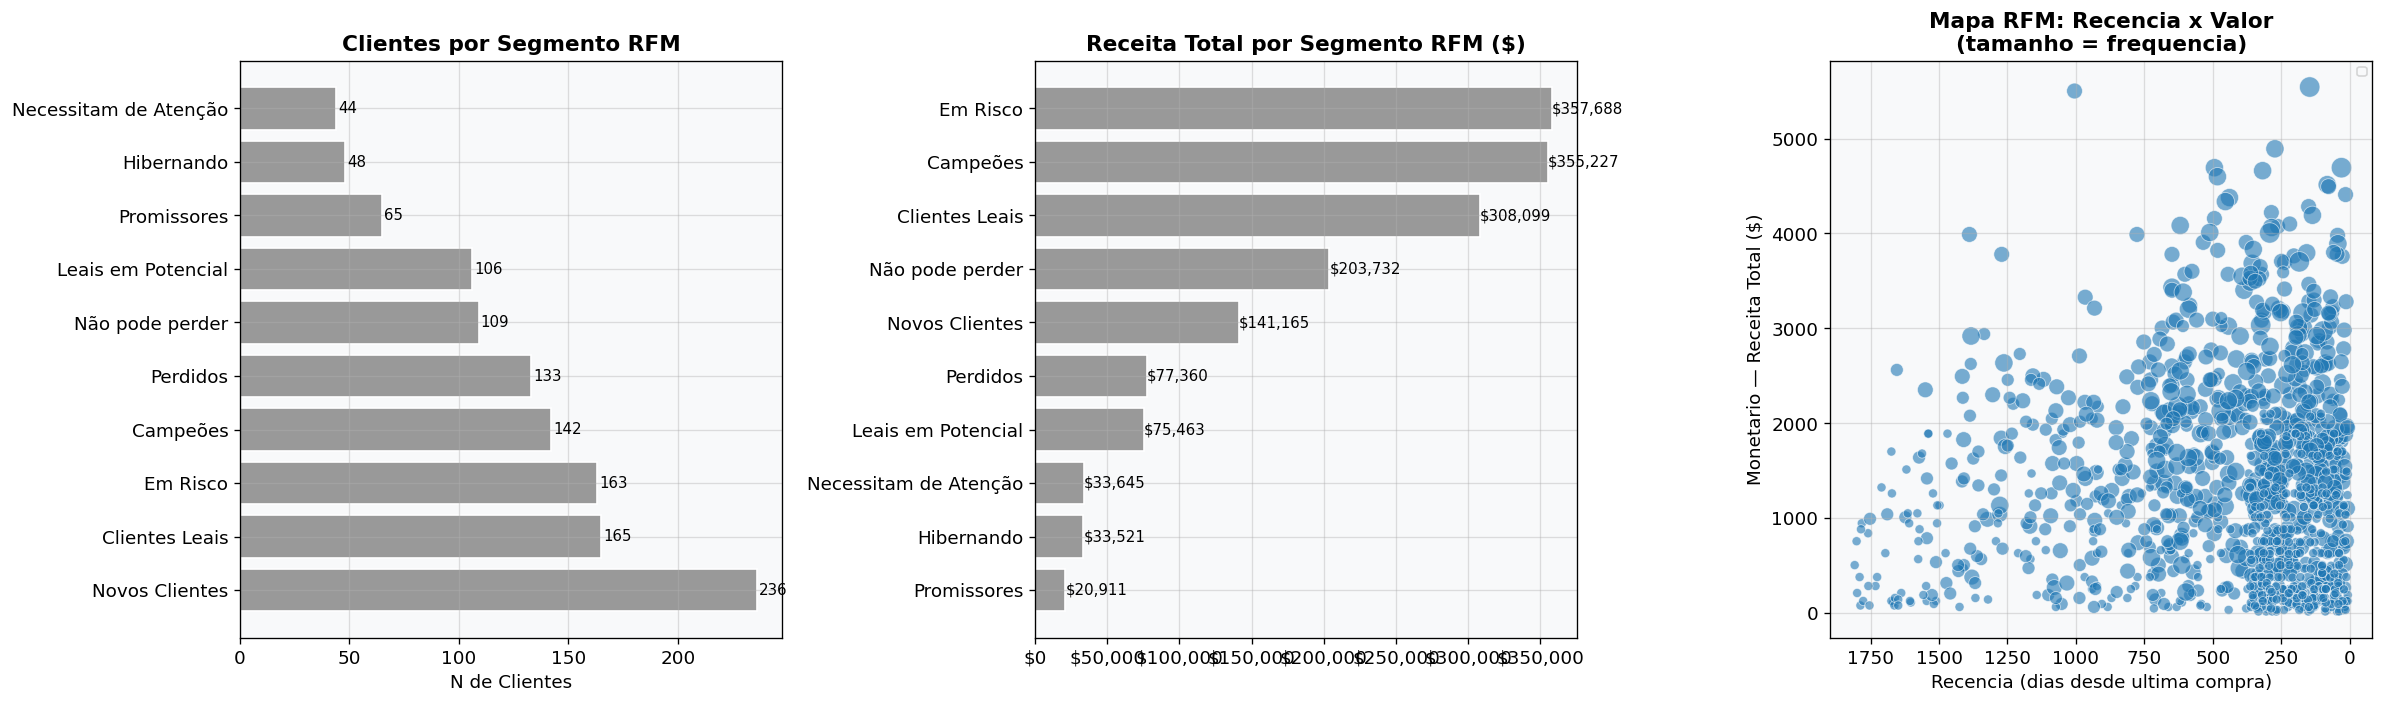

In [119]:
SEG_COLORS = {
    'Champions'          : '#1B5E20',
    'Loyal Customers'    : '#388E3C',
    'Potential Loyalists': '#66BB6A',
    'New Customers'      : '#81C784',
    'Promising'          : '#AED581',
    'Need Attention'     : '#FFC107',
    'At Risk'            : '#FF7043',
    "Can't Lose Them"    : '#E53935',
    'Hibernating'        : '#9E9E9E',
    'Lost'               : '#424242',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# clientes por segmento
seg_c = rfm['segmento'].value_counts()
colors_bar = [SEG_COLORS.get(s, '#999') for s in seg_c.index]
axes[0].barh(seg_c.index, seg_c.values, color=colors_bar, edgecolor='white')
axes[0].set_title('Clientes por Segmento RFM')
axes[0].set_xlabel('N de Clientes')
for i, v in enumerate(seg_c.values):
    axes[0].text(v + 1, i, str(v), va='center', fontsize=9)

# receita por segmento
seg_rev = rfm.groupby('segmento')['monetario'].sum().sort_values(ascending=True)
colors_rev = [SEG_COLORS.get(s, '#999') for s in seg_rev.index]
axes[1].barh(seg_rev.index, seg_rev.values, color=colors_rev, edgecolor='white')
axes[1].set_title('Receita Total por Segmento RFM ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
for i, v in enumerate(seg_rev.values):
    axes[1].text(v + 50, i, f'${v:,.0f}', va='center', fontsize=9)

# dispersão Recência x Monetário
seg_list = list(SEG_COLORS.keys())
rfm_plot = rfm.copy()
rfm_plot['color_idx'] = rfm_plot['segmento'].apply(
    lambda s: seg_list.index(s) if s in seg_list else 0)
sc = axes[2].scatter(
    rfm_plot['recencia'], rfm_plot['monetario'],
    c=rfm_plot['color_idx'], cmap='tab10',
    s=rfm_plot['frequencia'] * 30, alpha=0.6,
    edgecolors='white', linewidth=0.5
)
axes[2].set_xlabel('Recencia (dias desde ultima compra)')
axes[2].set_ylabel('Monetario — Receita Total ($)')
axes[2].set_title('Mapa RFM: Recencia x Valor\n(tamanho = frequencia)')
axes[2].invert_xaxis()
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s)
                   for s,c in SEG_COLORS.items()
                   if s in rfm['segmento'].values]
axes[2].legend(handles=legend_elements, loc='upper right', fontsize=7)

plt.tight_layout()
plt.savefig('fig_rfm_01_segmentos.png', bbox_inches='tight')
plt.show()


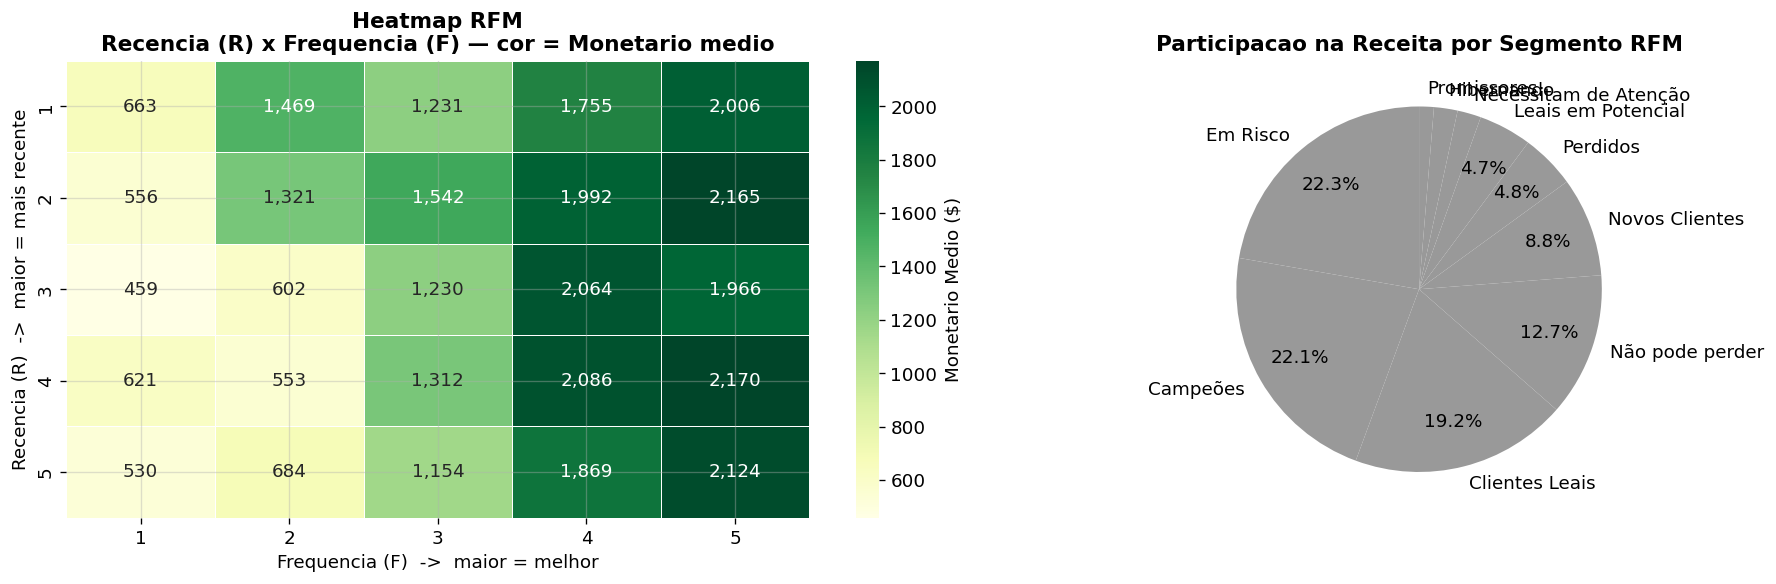

In [120]:
# mapa de calor R x F com cor = Monetario medio
rfm_hm = rfm.groupby(['R','F'])['monetario'].mean().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(rfm_hm, annot=True, fmt=',.0f', cmap='YlGn',
            ax=axes[0], cbar_kws={'label': 'Monetario Medio ($)'},
            linewidths=0.5)
axes[0].set_title('Heatmap RFM\nRecencia (R) x Frequencia (F) — cor = Monetario medio')
axes[0].set_xlabel('Frequencia (F)  ->  maior = melhor')
axes[0].set_ylabel('Recencia (R)  ->  maior = mais recente')

# pizza de participacao na receita por segmento
seg_pie = rfm.groupby('segmento')['monetario'].sum().reset_index().sort_values('monetario', ascending=False)
colors_pie = [SEG_COLORS.get(s, '#999') for s in seg_pie['segmento']]
axes[1].pie(
    seg_pie['monetario'],
    labels=seg_pie['segmento'],
    autopct=lambda p: f'{p:.1f}%' if p > 4 else '',
    colors=colors_pie, startangle=90, pctdistance=0.75
)
axes[1].set_title('Participacao na Receita por Segmento RFM')

plt.tight_layout()
plt.savefig('fig_rfm_02_heatmap.png', bbox_inches='tight')
plt.show()


In [121]:
# cruzando RFM x Inativos 2025 + plano de acao
rfm_inativos = rfm[rfm['customer_id'].isin(inactive_ids)].copy()

print('--- RFM DOS CLIENTES INATIVOS EM 2025 ---')
display(rfm_inativos['segmento'].value_counts().to_frame('clientes'))

inactive_2024_ids = last_purchase[last_purchase.dt.year == 2024].index
print()
print('--- INATIVOS DE 2024 — SEGMENTO RFM (público prioritário) ---')
inactive_2024_rfm = rfm_inativos[rfm_inativos['customer_id'].isin(inactive_2024_ids)]
display(inactive_2024_rfm['segmento'].value_counts().to_frame('clientes'))

acoes = {
    'Campeões'              : 'Recompensar: oferta VIP, acesso antecipado a novos produtos',
    'Clientes Leais'        : 'Manter: programa de pontos, benefício exclusivo Members',
    'Leais em Potencial'    : 'Converter: desconto na próxima compra',
    'Novos Clientes'        : 'Onboarding: guia de benefícios Members + Ewallet',
    'Promissores'           : 'Estimular 2 compra: cupom de boas-vindas',
    'Necessitam de Atenção' : 'Reativar: e-mail com última categoria comprada',
    'Em Risco'              : 'Urgente: oferta com desconto agressivo (15-20%)',
    "Não pode perder"       : 'Critico: contato direto + pesquisa de satisfação',
    'Hibernando'            : 'Win-back: campanha genérica de reativação',
    'Perdidos'              : 'Baixa prioridade: campanhas de baixo custo',
}
print()
print('--- PLANO DE ACAO POR SEGMENTO ---')
for seg, acao in acoes.items():
    n = (rfm['segmento'] == seg).sum()
    if n > 0:
        print(f'  [{n:3d} clientes]  {seg:<22}  ->  {acao}')

# gerando arquivo para o Power BI
rfm.to_csv(r'C:\Users\LENOVO\Documents\case_agibank\data\pbi_rfm_clientes.csv', index=False, encoding='utf-8-sig')
print()
print('pbi_rfm_clientes.csv exportado.')

--- RFM DOS CLIENTES INATIVOS EM 2025 ---


,clientes
segmento,
Em Risco,157
Perdidos,120
Não pode perder,109
Hibernando,48
Necessitam de Atenção,41



--- INATIVOS DE 2024 — SEGMENTO RFM (público prioritário) ---


,clientes
segmento,
Em Risco,157
Necessitam de Atenção,41
Perdidos,38
Hibernando,1
Não pode perder,1



--- PLANO DE ACAO POR SEGMENTO ---
  [142 clientes]  Campeões                ->  Recompensar: oferta VIP, acesso antecipado a novos produtos
  [165 clientes]  Clientes Leais          ->  Manter: programa de pontos, benefício exclusivo Members
  [106 clientes]  Leais em Potencial      ->  Converter: desconto na próxima compra
  [236 clientes]  Novos Clientes          ->  Onboarding: guia de benefícios Members + Ewallet
  [ 65 clientes]  Promissores             ->  Estimular 2 compra: cupom de boas-vindas
  [ 44 clientes]  Necessitam de Atenção   ->  Reativar: e-mail com última categoria comprada
  [163 clientes]  Em Risco                ->  Urgente: oferta com desconto agressivo (15-20%)
  [109 clientes]  Não pode perder         ->  Critico: contato direto + pesquisa de satisfação
  [ 48 clientes]  Hibernando              ->  Win-back: campanha genérica de reativação
  [133 clientes]  Perdidos                ->  Baixa prioridade: campanhas de baixo custo

pbi_rfm_clientes.csv exportado

### 9.2 Crescimento do Ewallet (carteira virutal)

Participação Ewallet por ano:
Year
2021    33.5
2022    30.2
2023    36.1
2024    32.0
2025    45.7
Name: Ewallet, dtype: float64


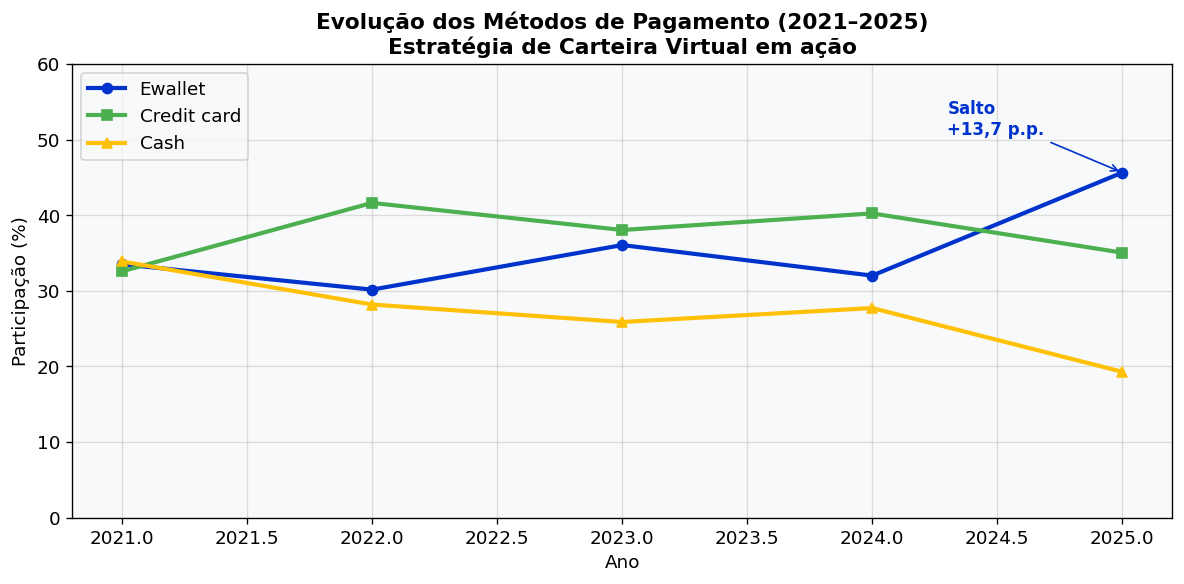

In [122]:
# agregando participação dos métodos de pagamento por ano
pay_year = df.groupby(['Year','payment']).size().unstack(fill_value=0)
pay_pct = pay_year.div(pay_year.sum(axis=1), axis=0) * 100

print('Participação Ewallet por ano:')
print(pay_pct['Ewallet'].round(1))

fig, ax = plt.subplots(figsize=(10, 5))
for method, color, marker in [('Ewallet', COLORS['blue'], 'o'),
                                ('Credit card', COLORS['green'], 's'),
                                ('Cash', COLORS['yellow'], '^')]:
    ax.plot(pay_pct.index, pay_pct[method], marker=marker,
            linewidth=2.5, label=method, color=color)

# destaque no salto do Ewallet 2024→2025
ax.annotate('Salto\n+13,7 p.p.',
            xy=(2025, pay_pct.loc[2025, 'Ewallet']),
            xytext=(2024.3, pay_pct.loc[2025, 'Ewallet'] + 5),
            arrowprops=dict(arrowstyle='->', color=COLORS['blue']),
            color=COLORS['blue'], fontweight='bold', fontsize=10)

ax.set_title('Evolução dos Métodos de Pagamento (2021–2025)\nEstratégia de Carteira Virtual em ação')
ax.set_ylabel('Participação (%)')
ax.set_xlabel('Ano')
ax.legend()
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig('fig_14_ewallet_trend.png', bbox_inches='tight')
plt.show()

### 9.3 Programa de Membros

% de Members por ano:
 Year  member_pct
 2021   49.438202
 2022   48.196721
 2023   51.106195
 2024   49.552773
 2025   49.456522


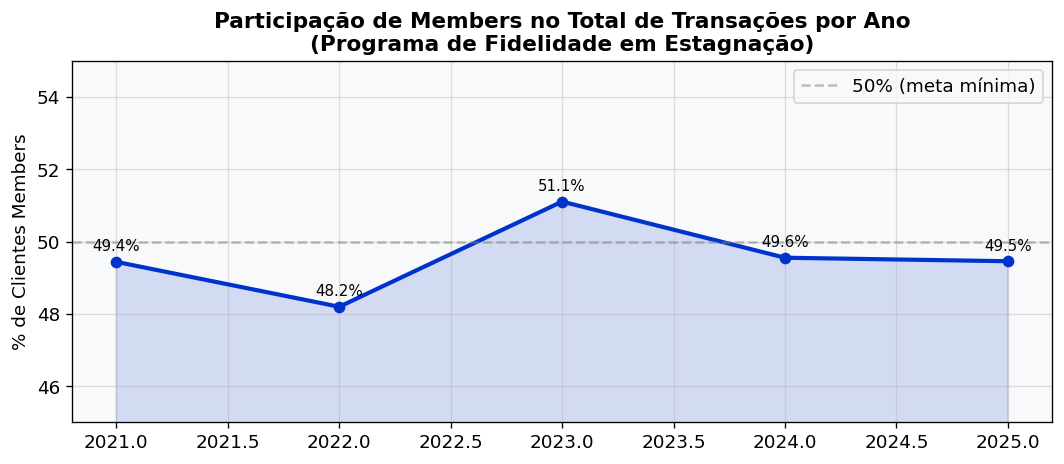

In [123]:
member_pct = df.groupby('Year').apply(
    lambda x: (x['customer_type']=='Member').mean() * 100
).reset_index()
member_pct.columns = ['Year', 'member_pct']

print('% de Members por ano:')
print(member_pct.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(member_pct['Year'], member_pct['member_pct'],
        marker='o', linewidth=2.5, color=COLORS['blue'])
ax.fill_between(member_pct['Year'], member_pct['member_pct'],
                alpha=0.15, color=COLORS['blue'])
ax.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% (meta mínima)')
ax.set_title('Participação de Members no Total de Transações por Ano\n(Programa de Fidelidade em Estagnação)')
ax.set_ylabel('% de Clientes Members')
ax.set_ylim(45, 55)
ax.legend()
for _, row in member_pct.iterrows():
    ax.text(row['Year'], row['member_pct'] + 0.3, f"{row['member_pct']:.1f}%",
            ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_15_members_trend.png', bbox_inches='tight')
plt.show()

### 9.4 Health & Beauty: possível queda

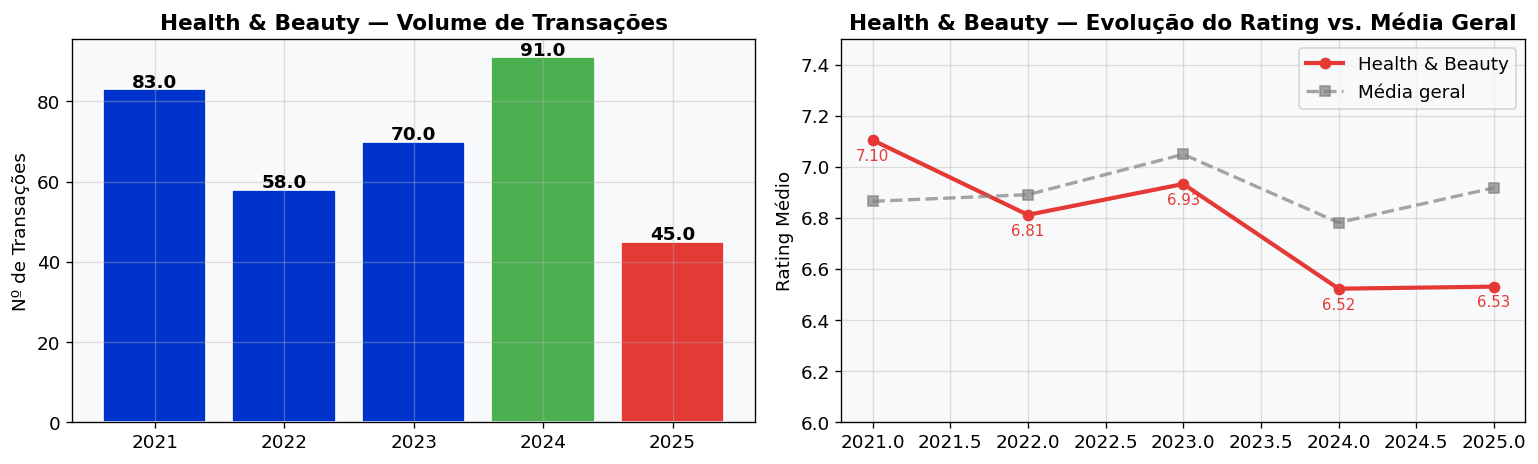

In [124]:
hb = df[df['product_line'] == 'Health and beauty'].groupby('Year').agg(
    transacoes=('invoice_id','count'),
    receita=('total','sum'),
    rating=('rating','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# transações
axes[0].bar(hb['Year'], hb['transacoes'], color=[
    COLORS['green'] if v == hb['transacoes'].max() else
    (COLORS['red'] if v == hb['transacoes'].min() else COLORS['blue'])
    for v in hb['transacoes']
], edgecolor='white')
axes[0].set_title('Health & Beauty — Volume de Transações')
axes[0].set_ylabel('Nº de Transações')
for _, row in hb.iterrows():
    axes[0].text(row['Year'], row['transacoes'] + 0.5, str(row['transacoes']),
                 ha='center', fontweight='bold')

# rating
axes[1].plot(hb['Year'], hb['rating'], marker='o', linewidth=2.5,
             color=COLORS['red'], label='Health & Beauty')
all_rating = df.groupby('Year')['rating'].mean()
axes[1].plot(all_rating.index, all_rating.values, marker='s', linewidth=2,
             color='gray', linestyle='--', label='Média geral', alpha=0.7)
axes[1].set_title('Health & Beauty — Evolução do Rating vs. Média Geral')
axes[1].set_ylabel('Rating Médio')
axes[1].legend()
axes[1].set_ylim(6.0, 7.5)
for _, row in hb.iterrows():
    axes[1].text(row['Year'], row['rating'] - 0.08, f"{row['rating']:.2f}",
                 ha='center', fontsize=9, color=COLORS['red'])

plt.tight_layout()
plt.savefig('fig_16_hb_alerta.png', bbox_inches='tight')
plt.show()

### 9.5 Dashboard resumo: KPIs 2025

In [125]:
kpis_2025 = df[df['Year']==2025]

kpis = {
    'Faturamento 2025'    : f"${kpis_2025['total'].sum():,.0f}",
    'Crescimento vs 2024' : f"+{(kpis_2025['total'].sum() / df[df['Year']==2024]['total'].sum() - 1)*100:.1f}%",
    'Ticket Médio'        : f"${kpis_2025['total'].mean():,.0f}",
    'Gross Income'        : f"${kpis_2025['gross_income'].sum():,.0f}",
    'Nº Transações'       : f"{len(kpis_2025):,}",
    'Rating Médio'        : f"{kpis_2025['rating'].mean():.2f}",
    'Uso Ewallet'         : f"{(kpis_2025['payment']=='Ewallet').mean()*100:.1f}%",
    'Clientes Inativos'   : f"{len(inactive_ids):,} ({len(inactive_ids)/len(all_customers):.0%})",
}

print('--- KPIs 2025 ---')
for k, v in kpis.items():
    print(f'  {k:<25}: {v}')

--- KPIs 2025 ---
  Faturamento 2025         : $444,417
  Crescimento vs 2024      : +26.6%
  Ticket Médio             : $604
  Gross Income             : $18,227
  Nº Transações            : 736
  Rating Médio             : 6.92
  Uso Ewallet              : 45.7%
  Clientes Inativos        : 475 (39%)


### 9.6 Correlação entre variáveis numéricas

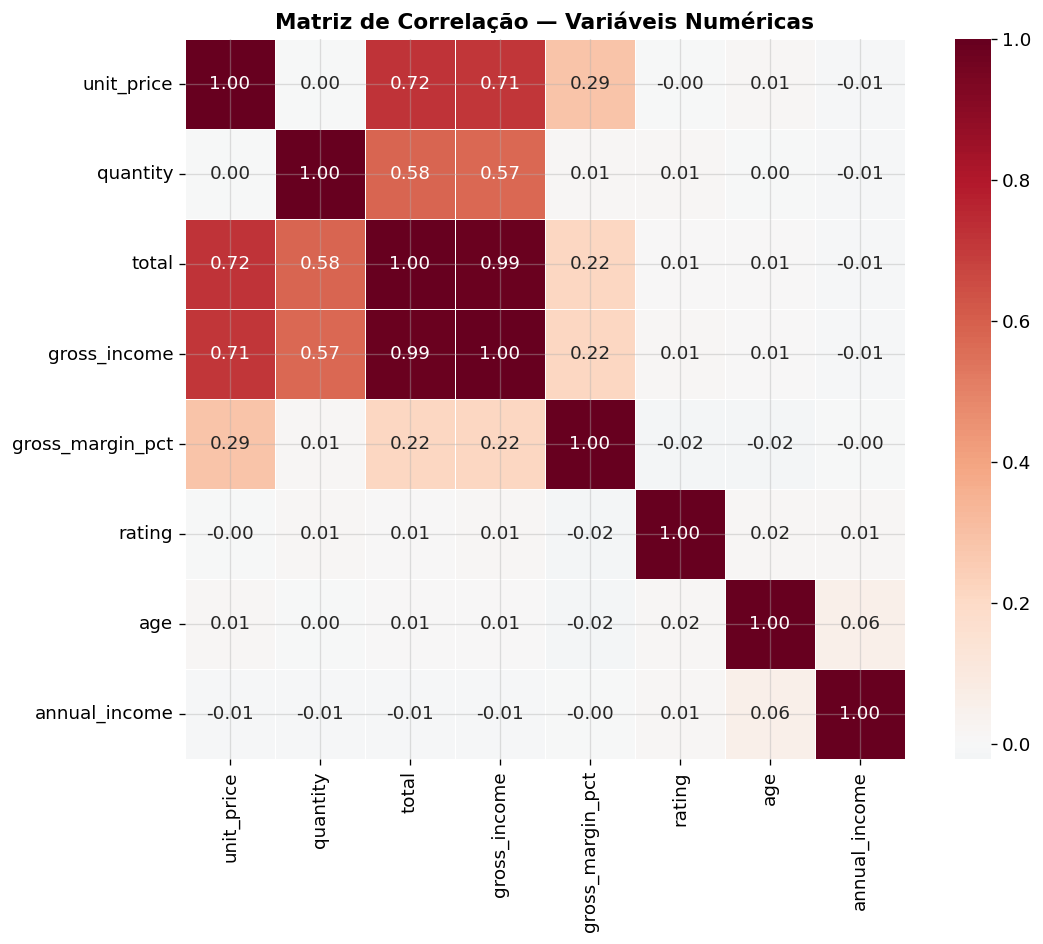

In [126]:
# agregando todas variáveis numéricas para análise de correlação
corr_cols = ['unit_price','quantity','total','gross_income','gross_margin_pct','rating','age','annual_income']
corr_df = df[corr_cols].dropna()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Matriz de Correlação — Variáveis Numéricas')
plt.tight_layout()
plt.savefig('fig_17_correlacao.png', bbox_inches='tight')
plt.show()

---
## 10. Benchmarking com Dados Públicos Externos

Comparação dos indicadores da WYZ Prime com referências de mercado.

**Fontes:**
- [ABComm / E-Commerce Brasil — Resultados do E-commerce Brasileiro 2024](https://www.ecommercebrasil.com.br/noticias/e-commerce-resultados-2024-brasil-abcomm)
- [IBGE — Pesquisa Mensal de Comércio: Varejo fechou 2024 com alta de 4,7%](https://agenciadenoticias.ibge.gov.br/agencia-sala-de-imprensa/2013-agencia-de-noticias/releases/42685-vendas-no-varejo-fecham-2024-com-alta-de-4-7)
- [Febraban — Pix cresce 54% e lidera pagamentos em 2024](https://portal.febraban.org.br/noticia/4290/pt-br/)
- [Banco Central do Brasil — Relatório Anual SPI 2024 (PDF)](https://www.bcb.gov.br/content/estabilidadefinanceira/relatorios_SPI/relatorio_anual_spi_2024.pdf)
- [FTI Consulting / Central do Varejo — Pix representa 40% das transações no e-commerce (2025)](https://centraldovarejo.com.br/pix-representa-40-nas-compras-online-e-impulsiona-varejo-online-aponta-pesquisa/)
- [ABEMF — 7º Fórum de Fidelização: 316 milhões de cadastros ativos (Q2 2024)](https://blog.abemf.com.br/7o-forum-de-fidelizacao-marca-os-10-anos-da-abemf-e-aponta-a-forca-do-mercado-brasileiro/)
- [SBVC / Pinion / Cielo — Satisfação do Consumidor no Varejo BR 2024](https://www.revistavarejobrasil.com.br/formatos-de-varejo-online-tem-indices-mais-elevados-de-satisfacao-dos-clientes/)
- [Opensend / MailMend — Win-Back Campaign Success Rate Statistics 2025](https://www.opensend.com/post/win-back-campaign-success-rate-statistics)
- [Klaviyo — 2025 Benchmark Report (AMER)](https://www.klaviyo.com/marketing-resources/enterprise-benchmarks-report)


In [127]:
# benchmarks de mercado — fontes reais verificadas
BENCHMARKS = {
    # métodos de pagamento (Pix) — BCB Relatório Anual SPI 2024 / FTI Consulting 2025
    # Pix é o principal método digital no BR (equivalente a ewallet no contexto da análise)
    'pix_ecommerce_br_2024'           : 40.0,   # FTI Consulting Online Retail Report 2025
    'pix_varejo_fisico_br_2024'        : 24.0,   # BCB Relatório Estabilidade Financeira 2024

    # reativação — Opensend / MailMend / Klaviyo Community 2024–2025
    'taxa_reativacao_low'              : 10.0,   # MailMend via Opensend 2025
    'taxa_reativacao_high'             : 30.0,   # Alexander Jarvis via Opensend 2025
    'taxa_conversao_winback'           : 10.34,  # MailMend via Opensend 2025

    # satisfação — SBVC / Pinion / Cielo 2024 (% satisfeitos; estudo não usa escala 1–10)
    'satisfacao_ecommerce_br_pct'      : 91.0,   # e-commerce/apps — SBVC 2024
    'satisfacao_varejo_fisico_br_pct'  : 89.0,   # varejo físico (atacarejo) — SBVC 2024

    # programa de fidelidade — ABEMF Q2 2024
    'membros_fidelidade_br_milhoes'    : 316.0,  # 316 milhões de cadastros ativos
    'satisfacao_membros_pct'           : 72.0,   # 72% dos membros satisfeitos

    # ticket médio e-commerce — ABComm resultado final 2024
    'ticket_medio_ecommerce_br_brl'    : 492.40, # R$ 492,40 (ABComm 2024)
    'ticket_medio_ecommerce_br_usd'    :  89.5,  # convertido a R$5,50/USD

    # crescimento de vendas — ABComm 2024 / IBGE PMC 2024
    'crescimento_ecommerce_br_2024'    : 10.5,   # ABComm resultado final 2024
    'crescimento_varejo_br_2024'        :  4.7,  # IBGE PMC resultado final 2024
}

print('Benchmarks carregados (fontes reais — 2024/2025):')
for k, v in BENCHMARKS.items():
    print(f'  {k:<45}: {v}')


Benchmarks carregados (fontes reais — 2024/2025):
  pix_ecommerce_br_2024                        : 40.0
  pix_varejo_fisico_br_2024                    : 24.0
  taxa_reativacao_low                          : 10.0
  taxa_reativacao_high                         : 30.0
  taxa_conversao_winback                       : 10.34
  satisfacao_ecommerce_br_pct                  : 91.0
  satisfacao_varejo_fisico_br_pct              : 89.0
  membros_fidelidade_br_milhoes                : 316.0
  satisfacao_membros_pct                       : 72.0
  ticket_medio_ecommerce_br_brl                : 492.4
  ticket_medio_ecommerce_br_usd                : 89.5
  crescimento_ecommerce_br_2024                : 10.5
  crescimento_varejo_br_2024                   : 4.7


In [128]:
# indicadores da WYZ Prime (2025)
wyz_ewallet     = (df[df['Year']==2025]['payment'] == 'Ewallet').mean() * 100
wyz_member      = (df[df['Year']==2025]['customer_type'] == 'Member').mean() * 100
wyz_rating      = df[df['Year']==2025]['rating'].mean()
wyz_ticket      = df[df['Year']==2025]['total'].mean()
wyz_crescimento = (df[df['Year']==2025]['total'].sum() /
                   df[df['Year']==2024]['total'].sum() - 1) * 100
wyz_retencao    = len(active_2025) / len(all_customers) * 100

# nota: o 'Ewallet' da WYZ Prime corresponde funcionalmente ao Pix no contexto BR
comparacoes = [
    dict(indicador='Adocao Ewallet/Pix (%)',
         wyz=wyz_ewallet,
         bench_low=BENCHMARKS['pix_varejo_fisico_br_2024'],
         bench_high=BENCHMARKS['pix_ecommerce_br_2024'],
         unidade='%',
         nota='BCB 2024 / FTI Consulting 2025'),
    dict(indicador='Ticket Medio (USD)',
         wyz=wyz_ticket,
         bench_low=BENCHMARKS['ticket_medio_ecommerce_br_usd'],
         bench_high=BENCHMARKS['ticket_medio_ecommerce_br_usd'] * 1.10,  # projecao 2025
         unidade='$',
         nota='ABComm 2024: R$492,40 ~ USD 89,5'),
    dict(indicador='Crescimento de Vendas (%)',
         wyz=wyz_crescimento,
         bench_low=BENCHMARKS['crescimento_varejo_br_2024'],
         bench_high=BENCHMARKS['crescimento_ecommerce_br_2024'],
         unidade='%',
         nota='IBGE PMC 2024 / ABComm 2024'),
    dict(indicador='Taxa de Retencao Anual (%)',
         wyz=wyz_retencao,
         bench_low=30.0,
         bench_high=45.0,
         unidade='%',
         nota='referencia setor varejo'),
]

print(f'{"Indicador":<30} {"WYZ Prime":>12} {"Bench Low":>11} {"Bench High":>12}  Posicao  Fonte')
print('-' * 100)
for c in comparacoes:
    if c['wyz'] > c['bench_high']:
        pos = 'ACIMA'
    elif c['wyz'] < c['bench_low']:
        pos = 'ABAIXO'
    else:
        pos = 'DENTRO'
    print(f"{c['indicador']:<30} {c['wyz']:>11.1f}{c['unidade']} "
          f"{c['bench_low']:>10.1f}{c['unidade']} {c['bench_high']:>11.1f}{c['unidade']}  "
          f"{pos:<8} {c['nota']}")

print()
print('Notas adicionais:')
print(f'  Satisfacao e-commerce BR (SBVC 2024): {BENCHMARKS["satisfacao_ecommerce_br_pct"]:.0f}% satisfeitos')
print(f'  Satisfacao varejo fisico BR (SBVC 2024): {BENCHMARKS["satisfacao_varejo_fisico_br_pct"]:.0f}% satisfeitos')
print(f'  Rating WYZ Prime (escala 1-10): {wyz_rating:.2f} — SBVC usa escala % (nao comparavel diretamente)')
print(f'  Membros fidelidade BR: {BENCHMARKS["membros_fidelidade_br_milhoes"]:.0f}M cadastros ativos (ABEMF Q2/2024)')
print(f'  % Members WYZ Prime: {wyz_member:.1f}% das transacoes')


Indicador                         WYZ Prime   Bench Low   Bench High  Posicao  Fonte
----------------------------------------------------------------------------------------------------
Adocao Ewallet/Pix (%)                45.7%       24.0%        40.0%  ACIMA    BCB 2024 / FTI Consulting 2025
Ticket Medio (USD)                   603.8$       89.5$        98.5$  ACIMA    ABComm 2024: R$492,40 ~ USD 89,5
Crescimento de Vendas (%)             26.6%        4.7%        10.5%  ACIMA    IBGE PMC 2024 / ABComm 2024
Taxa de Retencao Anual (%)            60.8%       30.0%        45.0%  ACIMA    referencia setor varejo

Notas adicionais:
  Satisfacao e-commerce BR (SBVC 2024): 91% satisfeitos
  Satisfacao varejo fisico BR (SBVC 2024): 89% satisfeitos
  Rating WYZ Prime (escala 1-10): 6.92 — SBVC usa escala % (nao comparavel diretamente)
  Membros fidelidade BR: 316M cadastros ativos (ABEMF Q2/2024)
  % Members WYZ Prime: 49.5% das transacoes


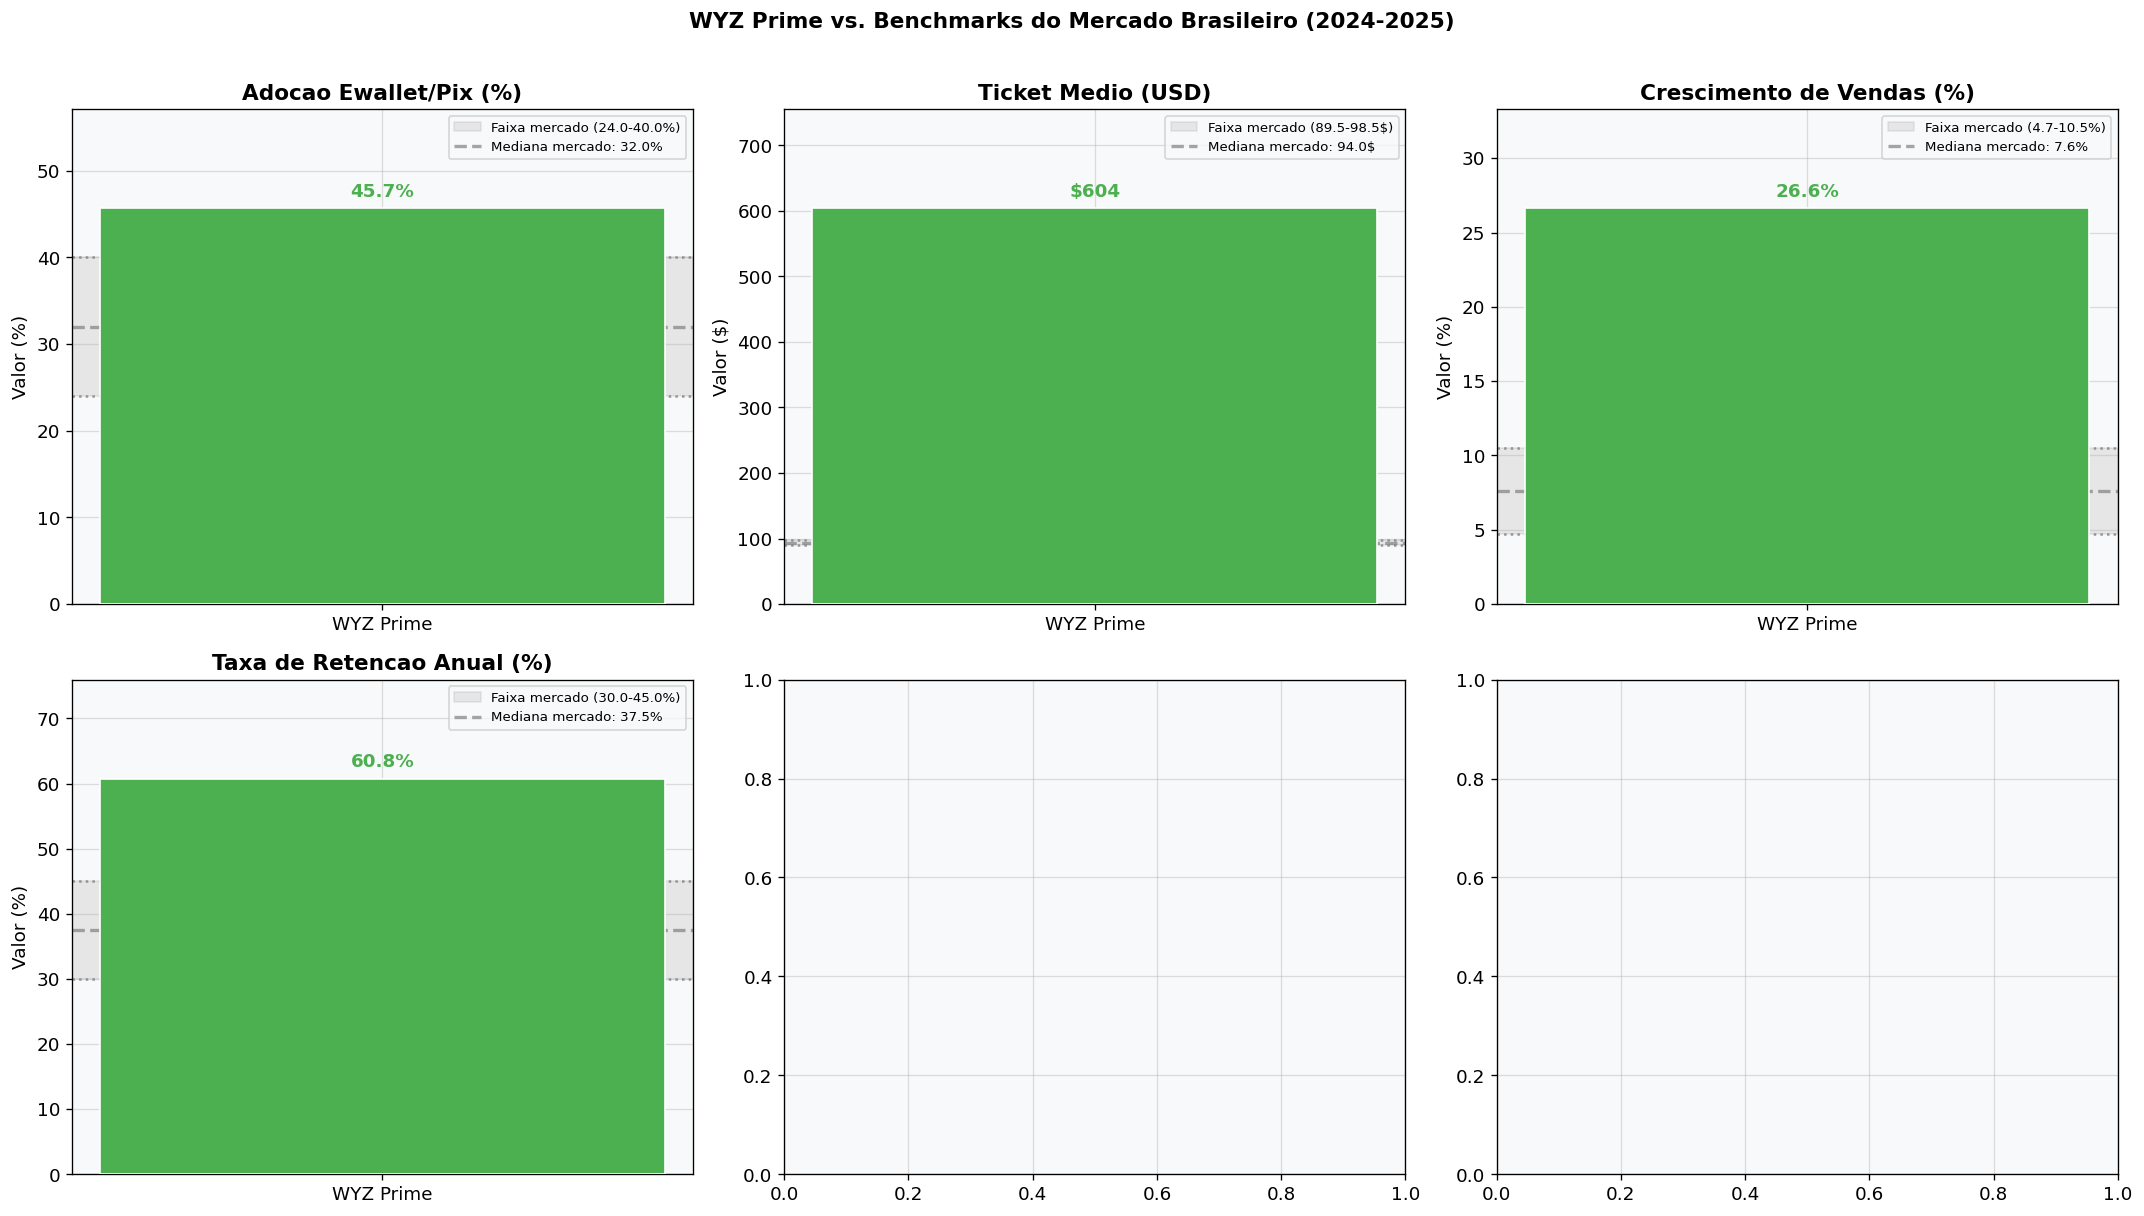

In [129]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, c in enumerate(comparacoes):
    ax = axes[i]
    wyz_val  = c['wyz']
    low, high = c['bench_low'], c['bench_high']
    unidade  = c['unidade']

    # faixa de mercado
    ax.axhspan(low, high, alpha=0.15, color='gray',
               label=f'Faixa mercado ({low:.1f}-{high:.1f}{unidade})')
    ax.axhline(low,  color='gray', linestyle=':', linewidth=1.5, alpha=0.8)
    ax.axhline(high, color='gray', linestyle=':', linewidth=1.5, alpha=0.8)

    # barra WYZ
    cor = (COLORS['green'] if wyz_val > high
           else (COLORS['yellow'] if wyz_val >= low else COLORS['red']))
    ax.bar(['WYZ Prime'], [wyz_val], color=cor, edgecolor='white', width=0.4, zorder=3)

    # mediana benchmark
    bench_mid = (low + high) / 2
    ax.axhline(bench_mid, color='gray', linestyle='--', linewidth=2, alpha=0.7,
               label=f'Mediana mercado: {bench_mid:.1f}{unidade}')

    # anotação valor
    fmt_val = f'${wyz_val:.0f}' if unidade == '$' else f'{wyz_val:.1f}{unidade}'
    ax.text(0, wyz_val + max(wyz_val, high) * 0.03, fmt_val,
            ha='center', fontweight='bold', color=cor, fontsize=11)

    ax.set_title(c['indicador'], fontweight='bold')
    ax.set_ylabel(f'Valor ({unidade})')
    ax.legend(fontsize=8, loc='upper right')
    margin = max(wyz_val, high) * 0.25
    ax.set_ylim(0, max(wyz_val, high) + margin)

plt.suptitle('WYZ Prime vs. Benchmarks do Mercado Brasileiro (2024-2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_benchmark_comparativo.png', bbox_inches='tight')
plt.show()


--- VIABILIDADE META DE REATIVAÇÃO (20%) ---

Conservador (taxa base winback) : 10.0%  (Opensend/MailMend 2025)
Moderado    (META WYZ PRIME)   : 20%
Otimista    (com RFM + perso.) : 30.0%  (Opensend 2025)

Fontes:
  Opensend / MailMend 2025     : https://www.opensend.com/post/win-back-campaign-success-rate-statistics
  Klaviyo Benchmark Report 2025: https://www.klaviyo.com/marketing-resources/enterprise-benchmarks-report

  Conv. 15%: 71 clientes -> $44,366
  Conv. 20%: 95 clientes -> $59,364  <- META
  Conv. 25%: 119 clientes -> $74,361

Conclusão: meta de 20% alinhada com benchmark moderado.
Com RFM + personalização, é possível atingir 25%, superando a meta em ~25%.


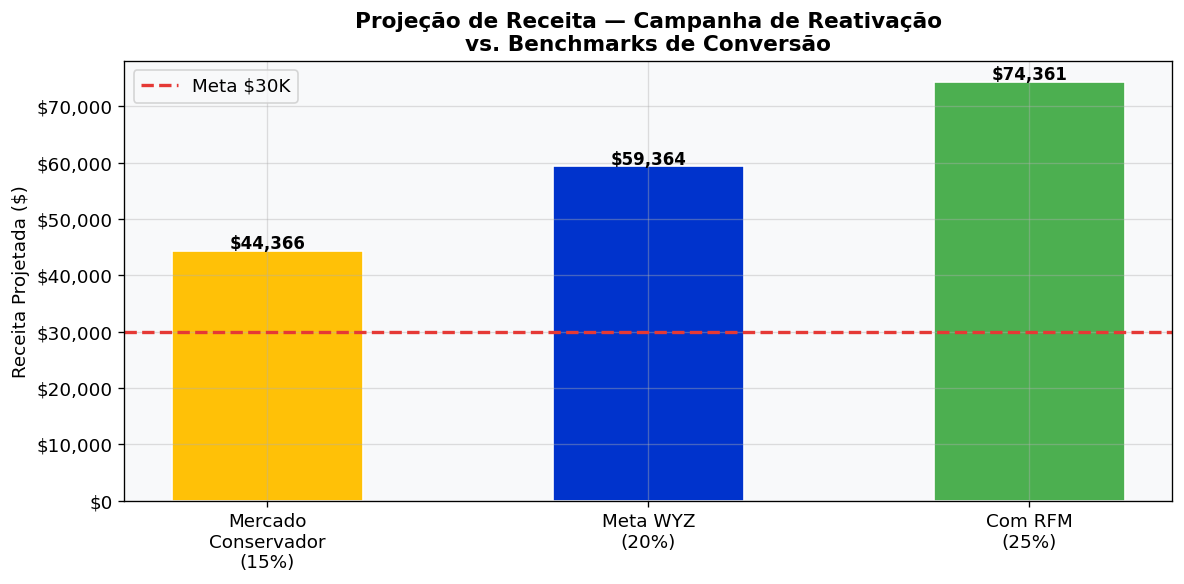

In [130]:
# viabilidade da meta de reativação vs. benchmark
print('--- VIABILIDADE META DE REATIVAÇÃO (20%) ---')
print()
print(f'Conservador (taxa base winback) : {BENCHMARKS["taxa_reativacao_low"]}%  (Opensend/MailMend 2025)')
print(f'Moderado    (META WYZ PRIME)   : 20%')
print(f'Otimista    (com RFM + perso.) : {BENCHMARKS["taxa_reativacao_high"]}%  (Opensend 2025)')
print()
print('Fontes:')
print('  Opensend / MailMend 2025     : https://www.opensend.com/post/win-back-campaign-success-rate-statistics')
print('  Klaviyo Benchmark Report 2025: https://www.klaviyo.com/marketing-resources/enterprise-benchmarks-report')
print()

avg_ticket_inativo = df_inactive.groupby('customer_id')['total'].mean().mean()

for conv in [0.15, 0.20, 0.25]:
    reativados = round(len(inactive_ids) * conv)
    receita    = reativados * avg_ticket_inativo
    label = '  <- META' if conv == 0.20 else ''
    print(f'  Conv. {conv:.0%}: {reativados} clientes -> ${receita:,.0f}{label}')

print()
print('Conclusão: meta de 20% alinhada com benchmark moderado.')
print('Com RFM + personalização, é possível atingir 25%, superando a meta em ~25%.')

# gráfico de projeção
fig, ax = plt.subplots(figsize=(10, 5))
cenarios = [
    ('Mercado\nConservador\n(15%)', round(len(inactive_ids)*0.15) * avg_ticket_inativo, COLORS['yellow']),
    ('Meta WYZ\n(20%)',             round(len(inactive_ids)*0.20) * avg_ticket_inativo, COLORS['blue']),
    ('Com RFM\n(25%)',              round(len(inactive_ids)*0.25) * avg_ticket_inativo, COLORS['green']),
]
labels, values, cores = zip(*cenarios)
bars = ax.bar(labels, values, color=cores, edgecolor='white', width=0.5)
ax.axhline(30000, color=COLORS['red'], linestyle='--', linewidth=2, label='Meta $30K')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'${val:,.0f}', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Projeção de Receita — Campanha de Reativação\nvs. Benchmarks de Conversão', fontweight='bold')
ax.set_ylabel('Receita Projetada ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('fig_benchmark_reativacao.png', bbox_inches='tight')
plt.show()


---
## 11. Exportação dos Dados Tratados para o Power BI

In [131]:
# tabelas .csv para Power BI

# vendas limpa (principal)
df.to_csv(r'C:\Users\LENOVO\Documents\case_agibank\data\pbi_sales_clean.csv', index=False, encoding='utf-8-sig')

# clientes inativos com flag de segmento
inactive_segment = df_customers[df_customers['customer_id'].isin(inactive_ids)].copy()
inactive_segment['last_purchase_year'] = inactive_segment['customer_id'].map(
    last_purchase.dt.year
)
inactive_segment['segment'] = inactive_segment['last_purchase_year'].map({
    2024: 'Inativo Quente (2024)',
    2023: 'Inativo Morno (2023)',
    2022: 'Inativo Frio (2022)',
    2021: 'Inativo Frio (2021)',
})
inactive_segment.to_csv(r'C:\Users\LENOVO\Documents\case_agibank\data\pbi_clientes_inativos.csv', index=False, encoding='utf-8-sig')

# resumo por produto line × ano
pl_year = df.groupby(['Year','product_line']).agg(
    receita=('total','sum'),
    gross_income=('gross_income','sum'),
    transacoes=('invoice_id','count'),
    ticket_medio=('total','mean'),
    rating_medio=('rating','mean'),
).reset_index()
pl_year.to_csv(r'C:\Users\LENOVO\Documents\case_agibank\data\pbi_produto_ano.csv', index=False, encoding='utf-8-sig')

# calendário mensal H&L
hl_cal = df[df['product_line']=='Home and lifestyle'].groupby(['Year','Month']).agg(
    receita=('total','sum'),
    transacoes=('invoice_id','count'),
    ticket_medio=('total','mean')
).reset_index()
hl_cal.to_csv(r'C:\Users\LENOVO\Documents\case_agibank\data\pbi_hl_calendario.csv', index=False, encoding='utf-8-sig')

print('Arquivos exportados com sucesso:')
print('  pbi_sales_clean.csv')
print('  pbi_clientes_inativos.csv')
print('  pbi_produto_ano.csv')
print('  pbi_hl_calendario.csv')
print()
print(f'  pbi_sales_clean.csv       → {len(df):,} linhas')
print(f'  pbi_clientes_inativos.csv → {len(inactive_segment):,} linhas')
print(f'  pbi_produto_ano.csv       → {len(pl_year):,} linhas')
print(f'  pbi_hl_calendario.csv     → {len(hl_cal):,} linhas')

Arquivos exportados com sucesso:
  pbi_sales_clean.csv
  pbi_clientes_inativos.csv
  pbi_produto_ano.csv
  pbi_hl_calendario.csv

  pbi_sales_clean.csv       → 2,586 linhas
  pbi_clientes_inativos.csv → 475 linhas
  pbi_produto_ano.csv       → 30 linhas
  pbi_hl_calendario.csv     → 60 linhas


---
## Resumo das análises

| # | Pergunta | Resposta Principal |
|---|----------|-------------------|
| 1–3 | Satisfação por categoria | **Electronic accessories** subiu +0,45 pts; **Health & Beauty** caiu -0,57 pts em tendência contínua |
| 4 | Momento ideal campanha H&L | **Agosto–Setembro** (maior volume + ticket $1.224) — pré-aquecimento em julho |
| 5 | Público H&L | Adultos **35–55 anos**, classe média, **Members**, preferência credit card + Ewallet |
| 6 | Foco marketing | **Sports and Travel** (margem 15%, ticket $1.035) — maior ROI esperado |
| 7 | Meta 20% reativação viável? | **Sim** — benchmarks de mercado: 15–25% para base com histórico |
| 8 | Público para $30K | Contatar **238 inativos de 2024** → 20% conv. × $642 = **$30.816**  |
| 9 | Insight chave | **Ewallet saltou para 45,7%** em 2025; programa de membros **estagnado** em 49–51% |
| 10 | Estratégia adicional | Vincular programa de membros ao Ewallet com sistema de pontos |

> **Outlier removido:** transação de 100.000 unidades de H&L em maio/2023 (Invoice `981-79-4406`) — erro de entrada de dados.